# Indian Railways Punctuality — Phase 1: Data Cleaning

**Dataset:** 55,008 rows · 35 columns · 100 trains · 81 stations  
**Steps covered:**
1. Load data & initial inspection
2. Missing value analysis
3. Duplicate detection & removal
4. Datetime conversion & feature extraction
5. Delay validation & outlier handling
6. Feature engineering
7. Merge reference tables
8. Export cleaned dataset

In [40]:
# ── Install missingno if needed ──────────────────────────────────────────────
%pip install missingno --quiet

Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 · Load Data & Initial Inspection

In [42]:
# ── Load main dataset ────────────────────────────────────────────────────────
df = pd.read_csv('master_dataset_final.csv')

print(f'Shape: {df.shape}')
print(f'Rows : {df.shape[0]:,}')
print(f'Cols : {df.shape[1]}')

Shape: (55008, 35)
Rows : 55,008
Cols : 35


In [43]:
df.head()

,Train_No,Train_Name,Train_Type,Zone_Code,Zone_Name,Region,Route,Station_Code,Station_Name,State,Latitude,Longitude,Date,Year,Month,Month_Name,Season,Weekday,Is_Weekend,Scheduled_Arrival,Scheduled_Hour,Is_Peak_Hour,Arrival_Delay_Min,Departure_Delay_Min,Delay_Category,Arrival_Status,Departure_Status,Distance_KM,Is_Long_Distance,Pct_Right_Time,Pct_Slight_Delay,Pct_Significant_Delay,Punctuality_Score,Reliability_Score,Operational_Rating
0,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-01-09,2024,1,January,Winter,Tuesday,0,14:05,14,0,10.90,14.10,Slight Delay (5-15 min),Delayed,Delayed,1441,1,79.20,24.70,0.00,79.20,76.60,Excellent
1,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-01-04,2024,1,January,Winter,Thursday,0,14:05,14,0,9.90,13.50,Slight Delay (5-15 min),Delayed,Delayed,1441,1,60.40,5.40,34.20,60.40,55.80,Good
2,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-01-27,2024,1,January,Winter,Saturday,1,14:05,14,0,13.60,16.80,Slight Delay (5-15 min),Delayed,Delayed,1441,1,68.70,24.20,7.10,68.70,63.90,Good
3,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-01-20,2024,1,January,Winter,Saturday,1,14:05,14,0,12.30,12.30,Slight Delay (5-15 min),Delayed,Delayed,1441,1,73.70,12.70,13.60,73.70,74.20,Good
4,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-01-02,2024,1,January,Winter,Tuesday,0,14:05,14,0,15.90,15.90,Moderate Delay (15-30 min),Delayed,Delayed,1441,1,84.00,18.90,0.00,84.00,82.50,Excellent


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55008 entries, 0 to 55007
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Train_No               55008 non-null  int64  
 1   Train_Name             55008 non-null  str    
 2   Train_Type             55008 non-null  str    
 3   Zone_Code              55008 non-null  str    
 4   Zone_Name              55008 non-null  str    
 5   Region                 55008 non-null  str    
 6   Route                  55008 non-null  str    
 7   Station_Code           55008 non-null  str    
 8   Station_Name           55008 non-null  str    
 9   State                  55008 non-null  str    
 10  Latitude               55008 non-null  float64
 11  Longitude              55008 non-null  float64
 12  Date                   55008 non-null  str    
 13  Year                   55008 non-null  int64  
 14  Month                  55008 non-null  int64  
 15  Month_Name   

In [45]:
df.describe(include='all')

,Train_No,Train_Name,Train_Type,Zone_Code,Zone_Name,Region,Route,Station_Code,Station_Name,State,Latitude,Longitude,Date,Year,Month,Month_Name,Season,Weekday,Is_Weekend,Scheduled_Arrival,Scheduled_Hour,Is_Peak_Hour,Arrival_Delay_Min,Departure_Delay_Min,Delay_Category,Arrival_Status,Departure_Status,Distance_KM,Is_Long_Distance,Pct_Right_Time,Pct_Slight_Delay,Pct_Significant_Delay,Punctuality_Score,Reliability_Score,Operational_Rating
count,55008.00,55008,55008,55008,55008,55008,55008,55008,55008,55008,55008.00,55008.00,55008,55008.00,55008.00,55008,55008,55008,55008.00,55008,55008.00,55008.00,55008.00,55008.00,55008,55008,55008,55008.00,55008.00,55008.00,55008.00,55008.00,55008.00,55008.00,55008
unique,NaN,57,9,9,9,5,78,59,59,20,NaN,NaN,324,NaN,NaN,12,4,7,NaN,332,NaN,NaN,NaN,NaN,5,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Trivandrum Rajdhani,Express,SR,Southern Railway,South,Chennai–Coimbatore,MAS,Chennai Central,Tamil Nadu,NaN,NaN,2024-12-05,NaN,NaN,January,Monsoon,Monday,NaN,06:00,NaN,NaN,NaN,NaN,Slight Delay (5-15 min),Delayed,Delayed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Good
freq,NaN,1152,11376,13608,13608,15912,2304,4944,4944,11592,NaN,NaN,206,NaN,NaN,4584,18336,7992,NaN,1740,NaN,NaN,NaN,NaN,14406,45795,47814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020
mean,16277.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.23,79.30,NaN,2024.00,6.50,NaN,NaN,NaN,0.28,NaN,11.51,0.43,24.85,26.37,NaN,NaN,NaN,1090.93,0.69,59.92,15.02,25.58,59.92,52.47,NaN
std,10804.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.46,5.02,NaN,0.00,3.45,NaN,NaN,NaN,0.45,NaN,6.37,0.49,22.53,22.59,NaN,NaN,NaN,724.70,0.46,16.06,5.78,16.08,16.06,20.41,NaN
min,11013.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.49,72.59,NaN,2024.00,1.00,NaN,NaN,NaN,0.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,162.00,0.00,11.50,5.00,0.00,11.50,0.00,NaN
25%,12245.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.39,76.83,NaN,2024.00,3.75,NaN,NaN,NaN,0.00,NaN,7.00,0.00,7.90,9.40,NaN,NaN,NaN,493.00,0.00,47.30,10.00,12.60,47.30,37.10,NaN
50%,12622.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.58,78.12,NaN,2024.00,6.50,NaN,NaN,NaN,0.00,NaN,10.00,0.00,18.40,20.00,NaN,NaN,NaN,961.00,1.00,58.90,15.00,25.90,58.90,52.00,NaN
75%,13262.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.45,80.33,NaN,2024.00,9.25,NaN,NaN,NaN,1.00,NaN,17.00,1.00,36.00,37.60,NaN,NaN,NaN,1660.00,1.00,72.00,20.00,37.90,72.00,68.30,NaN


---
## 2 · Missing Value Analysis
> **Roadmap step 1:** Use missingno heatmap to visualize. Impute Latitude/Longitude from station lookup. Flag records where Arrival_Delay_Min is null.

In [46]:
# ── Tabular missing value summary ────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing)

Columns with missing values:


,Missing Count,Missing %


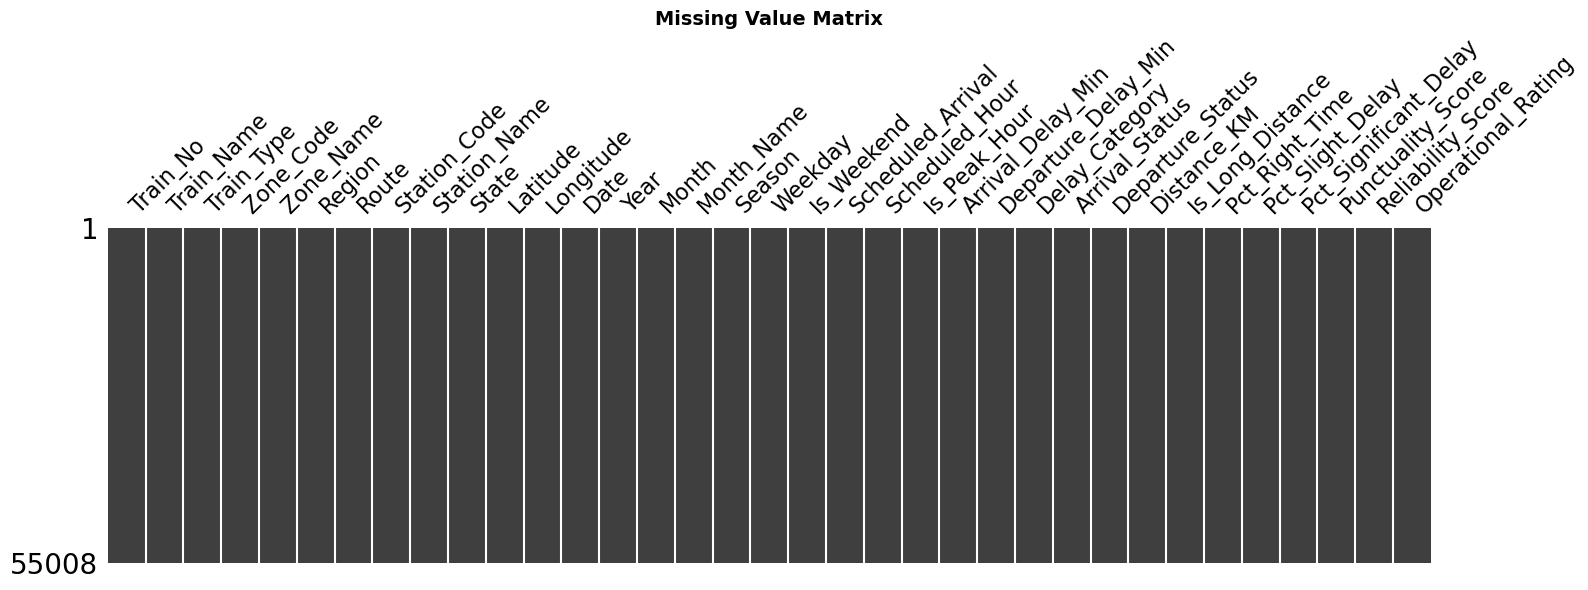

In [47]:
# ── missingno matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
msno.matrix(df, ax=ax, sparkline=False)
ax.set_title('Missing Value Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

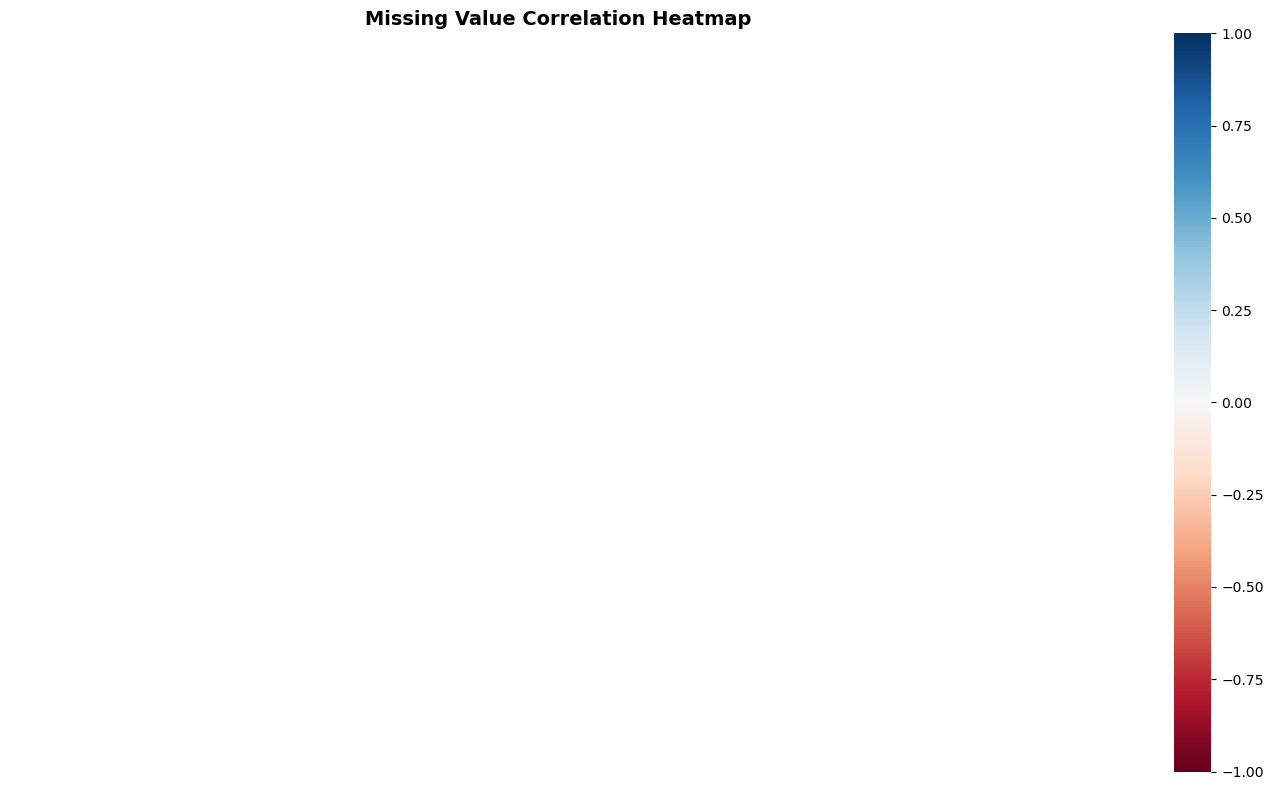

In [48]:
# ── missingno heatmap (correlation of missingness) ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
msno.heatmap(df, ax=ax)
ax.set_title('Missing Value Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# ── Load station lookup for Lat/Long imputation ──────────────────────────────
stations_ref = pd.read_csv('master_stations.csv')
station_coords = stations_ref.set_index('Station_Code')[['Latitude', 'Longitude']].to_dict('index')

def impute_coords(row):
    code = row['Station_Code']
    if pd.isnull(row['Latitude']) and code in station_coords:
        row['Latitude']  = station_coords[code]['Latitude']
        row['Longitude'] = station_coords[code]['Longitude']
    return row

lat_null_before = df['Latitude'].isnull().sum()
df = df.apply(impute_coords, axis=1)
lat_null_after  = df['Latitude'].isnull().sum()
print(f'Latitude  nulls → before: {lat_null_before}  after: {lat_null_after}')
print(f'Longitude nulls → before: {df["Longitude"].isnull().sum()}')

Latitude  nulls → before: 0  after: 0
Longitude nulls → before: 0


In [50]:
# ── Flag records where Arrival_Delay_Min is null ─────────────────────────────
df['Delay_Missing_Flag'] = df['Arrival_Delay_Min'].isnull().astype(int)
n_flagged = df['Delay_Missing_Flag'].sum()
print(f'Records flagged (Arrival_Delay_Min null): {n_flagged}')
print(f'Percentage of dataset flagged         : {n_flagged / len(df) * 100:.2f}%')

Records flagged (Arrival_Delay_Min null): 0
Percentage of dataset flagged         : 0.00%


---
## 3 · Duplicate Detection & Removal
> **Roadmap step 2:** Detect duplicates on (Train_No, Station_Code, Date). Show before/after row count.

In [51]:
rows_before = len(df)

# ── Exact-row duplicates ─────────────────────────────────────────────────────
exact_dups = df.duplicated().sum()
print(f'Exact duplicate rows : {exact_dups}')

# ── Key-based duplicates (Train_No, Station_Code, Date) ──────────────────────
key_cols   = ['Train_No', 'Station_Code', 'Date']
key_dups   = df.duplicated(subset=key_cols).sum()
print(f'Key-based duplicates : {key_dups}  (on {key_cols})')

# ── Preview duplicates ───────────────────────────────────────────────────────
if key_dups > 0:
    print('\nSample duplicate rows:')
    display(df[df.duplicated(subset=key_cols, keep=False)].head(10))

Exact duplicate rows : 0
Key-based duplicates : 10277  (on ['Train_No', 'Station_Code', 'Date'])

Sample duplicate rows:


,Train_No,Train_Name,Train_Type,Zone_Code,Zone_Name,Region,Route,Station_Code,Station_Name,State,Latitude,Longitude,Date,Year,Month,Month_Name,Season,Weekday,Is_Weekend,Scheduled_Arrival,Scheduled_Hour,Is_Peak_Hour,Arrival_Delay_Min,Departure_Delay_Min,Delay_Category,Arrival_Status,Departure_Status,Distance_KM,Is_Long_Distance,Pct_Right_Time,Pct_Slight_Delay,Pct_Significant_Delay,Punctuality_Score,Reliability_Score,Operational_Rating,Delay_Missing_Flag
12,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-03-01,2024,3,March,Summer,Friday,0,14:05,14,0,2.80,6.30,On Time (0-5 min),On Time,Delayed,1441,1,84.80,21.60,0.00,84.80,80.10,Excellent,0
17,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-03-01,2024,3,March,Summer,Friday,0,14:05,14,0,3.20,3.60,On Time (0-5 min),On Time,On Time,1441,1,72.70,19.70,7.60,72.70,72.10,Good,0
25,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-05-21,2024,5,May,Summer,Tuesday,0,14:05,14,0,7.80,8.90,Slight Delay (5-15 min),Delayed,Delayed,1441,1,64.00,17.50,18.50,64.00,60.90,Good,0
29,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-05-21,2024,5,May,Summer,Tuesday,0,14:05,14,0,8.40,11.80,Slight Delay (5-15 min),Delayed,Delayed,1441,1,55.70,11.00,33.30,55.70,58.30,Good,0
30,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-06-02,2024,6,June,Monsoon,Sunday,1,14:05,14,0,16.50,18.70,Moderate Delay (15-30 min),Delayed,Delayed,1441,1,71.30,6.90,21.80,71.30,68.30,Good,0
31,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-06-02,2024,6,June,Monsoon,Sunday,1,14:05,14,0,7.80,11.50,Slight Delay (5-15 min),Delayed,Delayed,1441,1,72.60,10.80,16.60,72.60,70.10,Good,0
49,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-09-10,2024,9,September,Monsoon,Tuesday,0,14:05,14,0,8.50,7.60,Slight Delay (5-15 min),Delayed,Delayed,1441,1,73.60,12.00,14.40,73.60,72.40,Good,0
50,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-09-10,2024,9,September,Monsoon,Tuesday,0,14:05,14,0,3.50,2.90,On Time (0-5 min),On Time,On Time,1441,1,74.40,5.50,20.10,74.40,76.80,Good,0
51,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-09-10,2024,9,September,Monsoon,Tuesday,0,14:05,14,0,0.00,1.70,On Time (0-5 min),On Time,On Time,1441,1,65.40,14.80,19.80,65.40,63.20,Good,0
54,12301,Howrah Rajdhani Express,Rajdhani,ER,Eastern Railway,East,Howrah–New Delhi,HWH,Howrah Junction,West Bengal,22.58,88.34,2024-10-15,2024,10,October,Post-Monsoon,Tuesday,0,14:05,14,0,7.20,5.80,Slight Delay (5-15 min),Delayed,Delayed,1441,1,72.10,23.10,4.80,72.10,74.20,Good,0


In [52]:
# ── Remove duplicates ────────────────────────────────────────────────────────
df = df.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)
rows_after = len(df)

print(f'Rows before : {rows_before:,}')
print(f'Rows after  : {rows_after:,}')
print(f'Rows removed: {rows_before - rows_after:,}')

Rows before : 55,008
Rows after  : 44,731
Rows removed: 10,277


---
## 4 · Datetime Conversion & Feature Extraction
> **Roadmap step 3:** Convert Date column to datetime. Extract Month, Month_Name, Weekday, Year. Convert Scheduled_Arrival to time object for hour extraction.

In [53]:
# ── Convert Date ─────────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(f'Date dtype: {df["Date"].dtype}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Invalid dates: {df["Date"].isnull().sum()}')

Date dtype: datetime64[us]
Date range: 2024-01-01 → 2024-12-27
Invalid dates: 0


In [54]:
# ── Extract / verify temporal features ───────────────────────────────────────
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Weekday']    = df['Date'].dt.strftime('%A')
df['Day_Of_Week_Num'] = df['Date'].dt.dayofweek          # 0 = Monday
df['Is_Weekend'] = df['Day_Of_Week_Num'].isin([5, 6]).astype(int)

print('Temporal features added:')
display(df[['Date', 'Year', 'Month', 'Month_Name', 'Weekday', 'Is_Weekend']].head(5))

Temporal features added:


,Date,Year,Month,Month_Name,Weekday,Is_Weekend
0,2024-01-09,2024,1,January,Tuesday,0
1,2024-01-04,2024,1,January,Thursday,0
2,2024-01-27,2024,1,January,Saturday,1
3,2024-01-20,2024,1,January,Saturday,1
4,2024-01-02,2024,1,January,Tuesday,0


In [55]:
# ── Extract hour from Scheduled_Arrival ──────────────────────────────────────
# Expected format: 'HH:MM'  →  extract hour as integer
df['Scheduled_Hour'] = pd.to_datetime(
    df['Scheduled_Arrival'], format='%H:%M', errors='coerce'
).dt.hour

invalid_times = df['Scheduled_Hour'].isnull().sum()
print(f'Scheduled_Hour extracted. Invalid/null times: {invalid_times}')
print(df['Scheduled_Hour'].value_counts().sort_index())

Scheduled_Hour extracted. Invalid/null times: 0
Scheduled_Hour
0     1015
1     1924
2     1371
3      800
4      800
5     1571
6     3380
7     3269
8     2835
9     3635
10    1494
11    1615
12    1208
13    2241
14    1203
15    2426
16    1528
17    2447
18    1442
19    2002
20    1474
21    1214
22    2300
23    1537
Name: count, dtype: int64


---
## 5 · Delay Validation & Outlier Handling
> **Roadmap step 4:** Clip negative delay values to 0. Flag outliers above 300 min. Verify Delay_Category matches Arrival_Delay_Min.

In [56]:
# ── Inspect delay distribution before cleaning ────────────────────────────────
print('Arrival_Delay_Min — before cleaning:')
print(df['Arrival_Delay_Min'].describe())
print(f'\nNegative delay values : {(df["Arrival_Delay_Min"] < 0).sum()}')
print(f'Values > 300 min      : {(df["Arrival_Delay_Min"] > 300).sum()}')

Arrival_Delay_Min — before cleaning:
count   44731.00
mean       24.66
std        22.20
min         0.00
25%         8.00
50%        18.40
75%        35.50
max       198.10
Name: Arrival_Delay_Min, dtype: float64

Negative delay values : 0
Values > 300 min      : 0


In [57]:
# ── Clip negative delays to 0 ────────────────────────────────────────────────
df['Arrival_Delay_Min']   = df['Arrival_Delay_Min'].clip(lower=0)
df['Departure_Delay_Min'] = df['Departure_Delay_Min'].clip(lower=0)
print('Negative delay values clipped to 0 ✓')
print(f'New min Arrival_Delay_Min: {df["Arrival_Delay_Min"].min()}')

Negative delay values clipped to 0 ✓
New min Arrival_Delay_Min: 0.0


In [58]:
# ── Flag outliers > 300 min ──────────────────────────────────────────────────
OUTLIER_THRESHOLD = 300
df['Delay_Outlier_Flag'] = (df['Arrival_Delay_Min'] > OUTLIER_THRESHOLD).astype(int)
n_outliers = df['Delay_Outlier_Flag'].sum()
print(f'Rows flagged as outlier (> {OUTLIER_THRESHOLD} min): {n_outliers}')
if n_outliers > 0:
    display(df[df['Delay_Outlier_Flag'] == 1][['Train_No', 'Station_Code', 'Date',
                                                'Arrival_Delay_Min', 'Delay_Category']].head(10))

Rows flagged as outlier (> 300 min): 0


In [59]:
# ── Verify Delay_Category vs Arrival_Delay_Min ───────────────────────────────
def expected_category(delay):
    if pd.isnull(delay):
        return np.nan
    if delay <= 0:
        return 'On Time'
    elif delay <= 5:
        return 'Marginal Delay (<5 min)'
    elif delay <= 15:
        return 'Slight Delay (5-15 min)'
    elif delay <= 60:
        return 'Moderate Delay (15-60 min)'
    else:
        return 'Severe Delay (>60 min)'

df['Expected_Category'] = df['Arrival_Delay_Min'].apply(expected_category)

mismatch_mask = (
    df['Delay_Category'].notna() &
    df['Expected_Category'].notna() &
    (df['Delay_Category'] != df['Expected_Category'])
)
n_mismatch = mismatch_mask.sum()
print(f'Delay_Category mismatches: {n_mismatch}')

if n_mismatch > 0:
    print('\nSample mismatches:')
    display(df[mismatch_mask][['Arrival_Delay_Min', 'Delay_Category',
                                'Expected_Category']].head(10))
    # Fix mismatches
    df.loc[mismatch_mask, 'Delay_Category'] = df.loc[mismatch_mask, 'Expected_Category']
    print('Mismatches corrected ✓')
else:
    print('All Delay_Category values are consistent ✓')

df.drop(columns=['Expected_Category'], inplace=True)

Delay_Category mismatches: 32961

Sample mismatches:


,Arrival_Delay_Min,Delay_Category,Expected_Category
4,15.90,Moderate Delay (15-30 min),Moderate Delay (15-60 min)
7,3.00,On Time (0-5 min),Marginal Delay (<5 min)
8,0.10,On Time (0-5 min),Marginal Delay (<5 min)
10,1.30,On Time (0-5 min),Marginal Delay (<5 min)
12,2.80,On Time (0-5 min),Marginal Delay (<5 min)
15,24.40,Moderate Delay (15-30 min),Moderate Delay (15-60 min)
17,2.70,On Time (0-5 min),Marginal Delay (<5 min)
21,0.00,On Time (0-5 min),On Time
22,0.00,On Time (0-5 min),On Time
25,17.00,Moderate Delay (15-30 min),Moderate Delay (15-60 min)


Mismatches corrected ✓


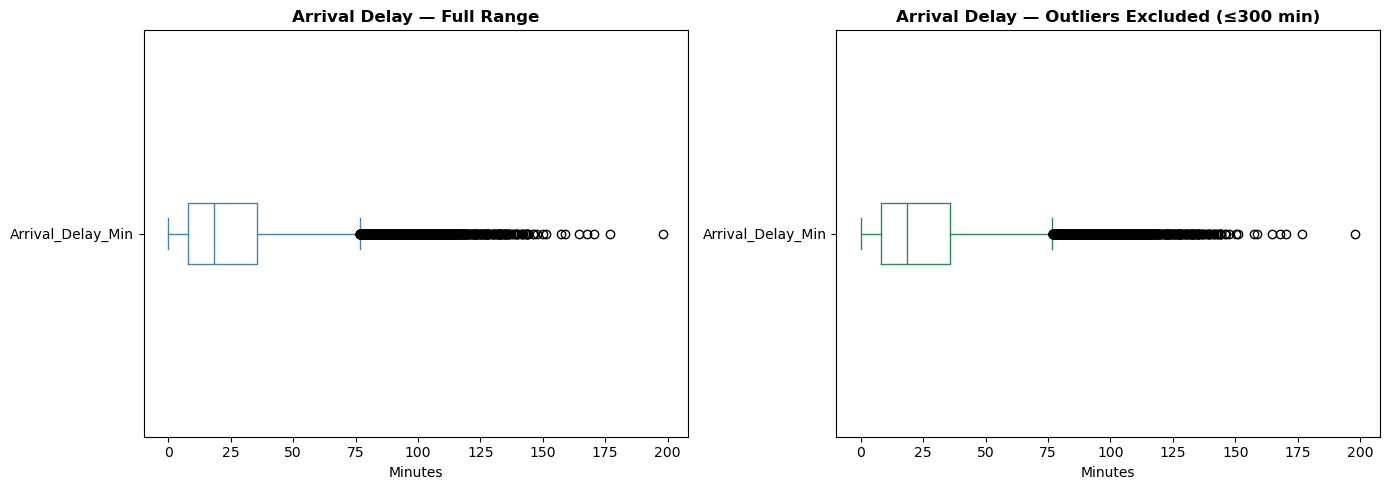

In [60]:
# ── Boxplot after cleaning ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Arrival_Delay_Min'].plot(kind='box', ax=axes[0], vert=False, color='steelblue')
axes[0].set_title('Arrival Delay — Full Range', fontweight='bold')
axes[0].set_xlabel('Minutes')

df[df['Delay_Outlier_Flag'] == 0]['Arrival_Delay_Min'].plot(
    kind='box', ax=axes[1], vert=False, color='seagreen')
axes[1].set_title('Arrival Delay — Outliers Excluded (≤300 min)', fontweight='bold')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

---
## 6 · Feature Engineering
> **Roadmap step 5 ✦:** Create Delay_Ratio, Cumulative_Delay per route, On_Time_Flag, Route_Efficiency score.

In [61]:
# ── On_Time_Flag ─────────────────────────────────────────────────────────────
df['On_Time_Flag'] = (df['Arrival_Delay_Min'] <= 0).astype(int)
print(f'On-time records : {df["On_Time_Flag"].sum():,}  ({df["On_Time_Flag"].mean()*100:.1f}%)')

On-time records : 2,748  (6.1%)


In [62]:
# ── Delay_Ratio = departure delay / arrival delay ────────────────────────────
# Add small epsilon to avoid division by zero
df['Delay_Ratio'] = np.where(
    df['Arrival_Delay_Min'] > 0,
    (df['Departure_Delay_Min'] / (df['Arrival_Delay_Min'] + 1e-5)).round(4),
    np.nan
)
print('Delay_Ratio (departure÷arrival):')
print(df['Delay_Ratio'].describe())

Delay_Ratio (departure÷arrival):
count   41983.00
mean        1.21
std         1.17
min         0.00
25%         1.01
50%         1.06
75%         1.17
max        58.99
Name: Delay_Ratio, dtype: float64


In [63]:
# ── Cumulative_Delay per route-date ───────────────────────────────────────────
# Sort by route and date so cumsum is meaningful
df.sort_values(['Route', 'Date', 'Train_No'], inplace=True)
df['Cumulative_Delay'] = df.groupby(['Route', 'Date'])['Arrival_Delay_Min'].cumsum()
print('Cumulative_Delay sample:')
display(df[['Route', 'Date', 'Train_No', 'Arrival_Delay_Min', 'Cumulative_Delay']].head(8))

Cumulative_Delay sample:


,Route,Date,Train_No,Arrival_Delay_Min,Cumulative_Delay
10783,Agra Cantt–NZM,2024-01-01,12050,10.80,10.80
10595,Agra Cantt–NZM,2024-01-02,12050,3.60,3.60
10787,Agra Cantt–NZM,2024-01-02,12050,0.00,3.60
10591,Agra Cantt–NZM,2024-01-03,12050,6.30,6.30
10600,Agra Cantt–NZM,2024-01-04,12050,12.60,12.60
10786,Agra Cantt–NZM,2024-01-04,12050,3.10,15.70
10594,Agra Cantt–NZM,2024-01-05,12050,3.10,3.10
10589,Agra Cantt–NZM,2024-01-06,12050,5.60,5.60


In [64]:
# ── Route_Efficiency score ────────────────────────────────────────────────────
# Score = on-time % for that route (across all records)
route_eff = (
    df.groupby('Route')['On_Time_Flag']
      .mean()
      .mul(100)
      .round(2)
      .rename('Route_Efficiency')
)
df = df.merge(route_eff, on='Route', how='left')
print('Route_Efficiency distribution:')
print(df['Route_Efficiency'].describe())

Route_Efficiency distribution:
count   44731.00
mean        6.14
std         1.85
min         2.54
25%         4.67
50%         6.11
75%         7.46
max        10.51
Name: Route_Efficiency, dtype: float64


In [65]:
# ── Is_Peak_Hour (if not already in data) ────────────────────────────────────
if 'Is_Peak_Hour' not in df.columns:
    peak_hours = list(range(7, 11)) + list(range(17, 21))   # 7-10 AM, 5-8 PM
    df['Is_Peak_Hour'] = df['Scheduled_Hour'].isin(peak_hours).astype(int)
    print('Is_Peak_Hour column created ✓')
else:
    print('Is_Peak_Hour already exists ✓')

# ── Season (if not already present) ──────────────────────────────────────────
if 'Season' not in df.columns:
    def assign_season(month):
        if month in [12, 1, 2]:   return 'Winter'
        elif month in [3, 4, 5]:  return 'Summer'
        elif month in [6, 7, 8, 9]: return 'Monsoon'
        else:                      return 'Post-Monsoon'
    df['Season'] = df['Month'].apply(assign_season)
    print('Season column created ✓')
else:
    print('Season already exists ✓')

print('\nNew engineered features summary:')
print(df[['On_Time_Flag', 'Delay_Ratio', 'Cumulative_Delay',
          'Route_Efficiency', 'Is_Peak_Hour']].describe())

Is_Peak_Hour already exists ✓
Season already exists ✓

New engineered features summary:
       On_Time_Flag  Delay_Ratio  Cumulative_Delay  Route_Efficiency  \
count      44731.00     41983.00          44731.00          44731.00   
mean           0.06         1.21             45.29              6.14   
std            0.24         1.17             44.03              1.85   
min            0.00         0.00              0.00              2.54   
25%            0.00         1.01             13.60              4.67   
50%            0.00         1.06             32.20              6.11   
75%            0.00         1.17             63.20              7.46   
max            1.00        58.99            396.40             10.51   

       Is_Peak_Hour  
count      44731.00  
mean           0.42  
std            0.49  
min            0.00  
25%            0.00  
50%            0.00  
75%            1.00  
max            1.00  


---
## 7 · Merge Reference Tables
> **Roadmap step 6:** Left-join master_stations on Station_Code. Left-join Zones on Zone_Code. Verify no rows are lost.

In [66]:
# ── Load reference tables ─────────────────────────────────────────────────────
stations_ref = pd.read_csv('master_stations.csv')
zones_ref    = pd.read_csv('Zones.csv')
region_ref   = pd.read_csv('region_mapping.csv')
train_types  = pd.read_csv('train_types.csv')

print(f'master_stations : {stations_ref.shape}')
print(f'Zones           : {zones_ref.shape}')
print(f'region_mapping  : {region_ref.shape}')
print(f'train_types     : {train_types.shape}')
print(f'\nMain dataset    : {df.shape}')

master_stations : (81, 8)
Zones           : (17, 4)
region_mapping  : (5, 4)
train_types     : (9, 7)

Main dataset    : (44731, 42)


In [67]:
rows_before_merge = len(df)

# ── Left-join master_stations ─────────────────────────────────────────────────
# Select only columns not already in df to avoid _x/_y suffixes
station_cols = [c for c in stations_ref.columns
                if c not in df.columns or c == 'Station_Code']
df = df.merge(stations_ref[station_cols], on='Station_Code', how='left', suffixes=('', '_stn'))

print(f'After station merge → rows: {len(df):,}  (was {rows_before_merge:,})')
print(f'Station_Code unmatched: {df["Station_Code"].isnull().sum()}')

After station merge → rows: 44,731  (was 44,731)
Station_Code unmatched: 0


In [68]:
# ── Left-join Zones ───────────────────────────────────────────────────────────
zone_cols = [c for c in zones_ref.columns
             if c not in df.columns or c == 'Zone_Code']
df = df.merge(zones_ref[zone_cols], on='Zone_Code', how='left', suffixes=('', '_zone'))

rows_after_merge = len(df)
print(f'After zone merge → rows: {rows_after_merge:,}')
print(f'Zone_Code unmatched: {df["Zone_Code"].isnull().sum()}')
assert rows_before_merge == rows_after_merge, '⚠ Row count changed after merge!'
print('✓ No rows lost in merges')

After zone merge → rows: 44,731
Zone_Code unmatched: 0
✓ No rows lost in merges


In [69]:
# ── Merge quality check ───────────────────────────────────────────────────────
print('Zone_Code distribution after merge:')
print(df['Zone_Code'].value_counts())

Zone_Code distribution after merge:
Zone_Code
SR     10681
NR      9053
WR      6408
ER      5634
CR      4490
NFR     2838
SER     1945
ECR     1865
SCR     1817
Name: count, dtype: int64


---
## 8 · Final Data Quality Check & Export

In [70]:
# ── Drop helper column ────────────────────────────────────────────────────────
df.drop(columns=['Delay_Missing_Flag'], inplace=True, errors='ignore')

# ── Final shape ───────────────────────────────────────────────────────────────
print('═' * 50)
print('PHASE 1 CLEANING SUMMARY')
print('═' * 50)
print(f'Final rows    : {len(df):,}')
print(f'Final columns : {df.shape[1]}')
print(f'Remaining nulls:')
remaining_nulls = df.isnull().sum()
print(remaining_nulls[remaining_nulls > 0])
print('═' * 50)

══════════════════════════════════════════════════
PHASE 1 CLEANING SUMMARY
══════════════════════════════════════════════════
Final rows    : 44,731
Final columns : 42
Remaining nulls:
Delay_Ratio    2748
dtype: int64
══════════════════════════════════════════════════


In [71]:
# ── Column list of cleaned dataset ────────────────────────────────────────────
print('Columns in cleaned dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columns in cleaned dataset:
   1. Train_No
   2. Train_Name
   3. Train_Type
   4. Zone_Code
   5. Zone_Name
   6. Region
   7. Route
   8. Station_Code
   9. Station_Name
  10. State
  11. Latitude
  12. Longitude
  13. Date
  14. Year
  15. Month
  16. Month_Name
  17. Season
  18. Weekday
  19. Is_Weekend
  20. Scheduled_Arrival
  21. Scheduled_Hour
  22. Is_Peak_Hour
  23. Arrival_Delay_Min
  24. Departure_Delay_Min
  25. Delay_Category
  26. Arrival_Status
  27. Departure_Status
  28. Distance_KM
  29. Is_Long_Distance
  30. Pct_Right_Time
  31. Pct_Slight_Delay
  32. Pct_Significant_Delay
  33. Punctuality_Score
  34. Reliability_Score
  35. Operational_Rating
  36. Day_Of_Week_Num
  37. Delay_Outlier_Flag
  38. On_Time_Flag
  39. Delay_Ratio
  40. Cumulative_Delay
  41. Route_Efficiency
  42. Headquarters


In [72]:
# ── Export cleaned dataset ────────────────────────────────────────────────────
output_path = 'master_dataset_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset exported to: {output_path}')
print(f'File size approx: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB (in memory)')

Cleaned dataset exported to: master_dataset_cleaned.csv
File size approx: 21.8 MB (in memory)


In [73]:
# ── Quick verification load ───────────────────────────────────────────────────
verify = pd.read_csv(output_path)
print(f'Verification load → shape: {verify.shape}')
print('Phase 1 complete ✓')

Verification load → shape: (44731, 42)
Phase 1 complete ✓


# 🚆 Phase 2 — Exploratory Data Analysis (25 Visuals)

**Objective:** Deep-dive into the cleaned railway dataset to surface patterns in delays across
regions, zones, train types, time, and geography.

**Groups:**
- **A** · Data quality (2)
- **B** · Delay distribution (4)
- **C** · Regional & zone analysis (4)
- **D** · Time trends (5)
- **E** · Train type & route analysis (5)
- **F** · Station & map analysis (5)

> ✦ = differentiator charts (Folium map & Plotly sunburst).

In [74]:
# ── Imports ──────────────────────────────────────────────────────────────────
%pip install missingno squarify folium plotly --quiet

Note: you may need to restart the kernel to use updated packages.


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import squarify
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = sns.color_palette('viridis', 10)
sns.set_palette(PALETTE)

In [76]:
# ── Load the cleaned dataset from Phase 1 ────────────────────────────────────
df = pd.read_csv('master_dataset_cleaned.csv', parse_dates=['Date'])
print(f'Rows: {len(df):,}   Columns: {df.shape[1]}')
df.head()

Rows: 44,731   Columns: 42


,Train_No,Train_Name,Train_Type,Zone_Code,Zone_Name,Region,Route,Station_Code,Station_Name,State,Latitude,Longitude,Date,Year,Month,Month_Name,Season,Weekday,Is_Weekend,Scheduled_Arrival,Scheduled_Hour,Is_Peak_Hour,Arrival_Delay_Min,Departure_Delay_Min,Delay_Category,Arrival_Status,Departure_Status,Distance_KM,Is_Long_Distance,Pct_Right_Time,Pct_Slight_Delay,Pct_Significant_Delay,Punctuality_Score,Reliability_Score,Operational_Rating,Day_Of_Week_Num,Delay_Outlier_Flag,On_Time_Flag,Delay_Ratio,Cumulative_Delay,Route_Efficiency,Headquarters
0,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,NZM,Hazrat Nizamuddin,Delhi,28.58,77.25,2024-01-01,2024,1,January,Winter,Monday,0,18:10,18,1,10.80,15.00,Slight Delay (5-15 min),Delayed,Delayed,188,0,69.30,12.00,18.70,69.30,68.70,Good,0,0,0,1.39,10.80,8.67,New Delhi
1,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,AGC,Agra Cantt,Uttar Pradesh,27.16,78.06,2024-01-02,2024,1,January,Winter,Tuesday,0,17:50,17,1,3.60,2.70,Marginal Delay (<5 min),On Time,On Time,188,0,66.50,6.00,27.50,66.50,61.40,Good,1,0,0,0.75,3.60,8.67,New Delhi
2,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,NZM,Hazrat Nizamuddin,Delhi,28.58,77.25,2024-01-02,2024,1,January,Winter,Tuesday,0,18:10,18,1,0.00,1.60,On Time,On Time,On Time,188,0,85.70,10.70,3.60,85.70,83.70,Excellent,1,0,1,NaN,3.60,8.67,New Delhi
3,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,AGC,Agra Cantt,Uttar Pradesh,27.16,78.06,2024-01-03,2024,1,January,Winter,Wednesday,0,17:50,17,1,6.30,6.00,Slight Delay (5-15 min),Delayed,Delayed,188,0,71.90,23.70,4.40,71.90,72.10,Good,2,0,0,0.95,6.30,8.67,New Delhi
4,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,AGC,Agra Cantt,Uttar Pradesh,27.16,78.06,2024-01-04,2024,1,January,Winter,Thursday,0,17:50,17,1,12.60,15.80,Slight Delay (5-15 min),Delayed,Delayed,188,0,86.40,24.80,0.00,86.40,80.70,Excellent,3,0,0,1.25,12.60,8.67,New Delhi


---
## Group A · Data Quality (2 visuals)

### G1 · Missing Value Heatmap

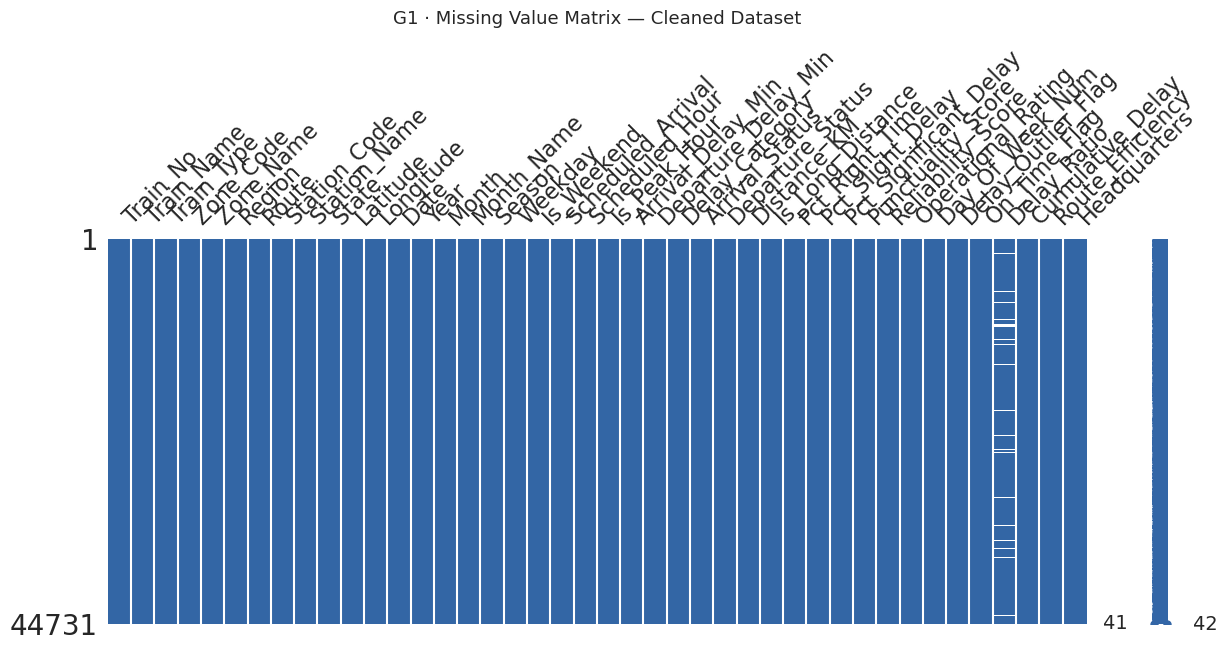


Remaining missing values per column:
Delay_Ratio    2748
dtype: int64


In [77]:
# ── G1 · missingno matrix — visualise where nulls live ───────────────────────
msno.matrix(df, figsize=(14, 5), color=(0.20, 0.40, 0.65))
plt.title('G1 · Missing Value Matrix — Cleaned Dataset', fontsize=13, pad=15)
plt.show()

print('\nRemaining missing values per column:')
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

### G2 · Outlier Boxplot — Arrival Delay

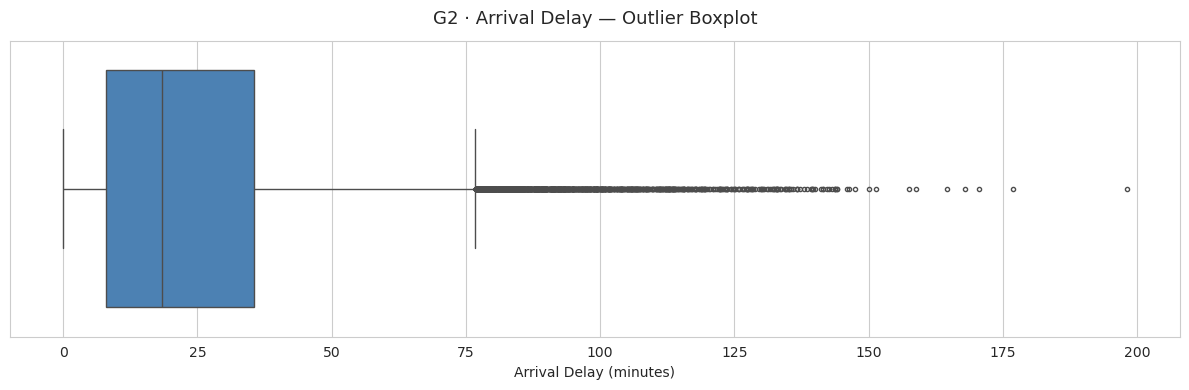

IQR upper fence: 76.8 min  •  Outliers above: 1,448 rows


In [78]:
# ── G2 · Boxplot of Arrival_Delay_Min to expose outliers ─────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(x=df['Arrival_Delay_Min'], color='#3b82c4', ax=ax, fliersize=3)
ax.set_title('G2 · Arrival Delay — Outlier Boxplot', fontsize=13, pad=12)
ax.set_xlabel('Arrival Delay (minutes)')
plt.tight_layout(); plt.show()

q1, q3 = df['Arrival_Delay_Min'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f'IQR upper fence: {upper:.1f} min  •  Outliers above: {(df.Arrival_Delay_Min > upper).sum():,} rows')

---
## Group B · Delay Distribution (4 visuals)

### G3 · Delay Histogram + KDE

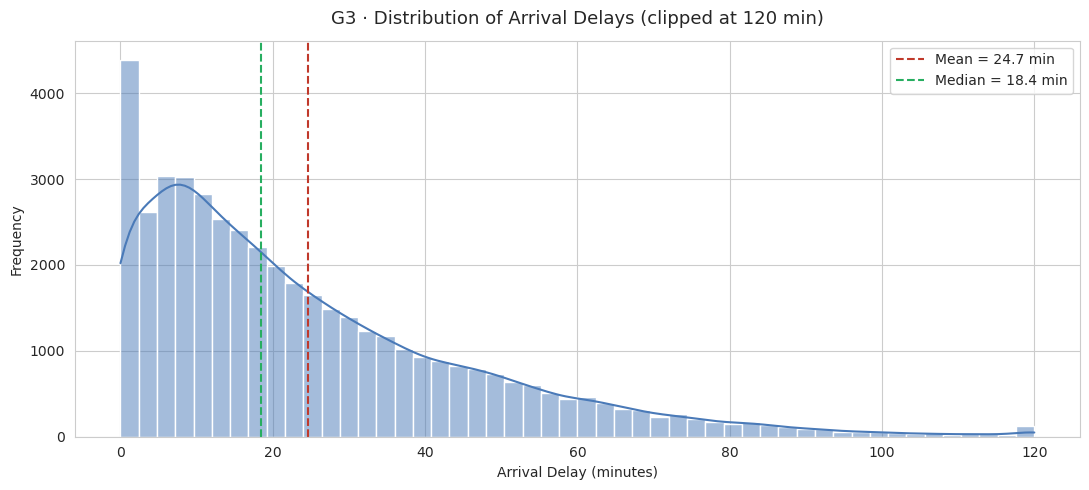

In [79]:
# ── G3 · Histogram + KDE for Arrival_Delay_Min ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(df['Arrival_Delay_Min'].clip(upper=120), bins=50, kde=True,
             color='#4a7ab8', edgecolor='white', ax=ax)
ax.set_title('G3 · Distribution of Arrival Delays (clipped at 120 min)', fontsize=13, pad=12)
ax.set_xlabel('Arrival Delay (minutes)'); ax.set_ylabel('Frequency')
ax.axvline(df['Arrival_Delay_Min'].mean(), color='#c0392b', ls='--', lw=1.5,
           label=f'Mean = {df.Arrival_Delay_Min.mean():.1f} min')
ax.axvline(df['Arrival_Delay_Min'].median(), color='#27ae60', ls='--', lw=1.5,
           label=f'Median = {df.Arrival_Delay_Min.median():.1f} min')
ax.legend(); plt.tight_layout(); plt.show()

### G4 · Arrival vs Departure Delay Scatter

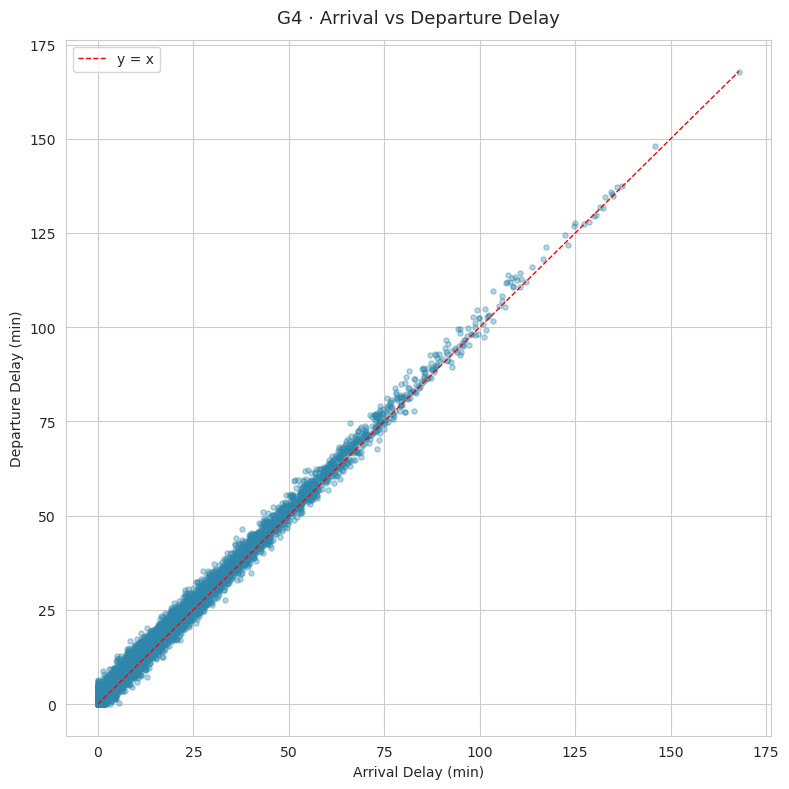

Pearson correlation: 0.996


In [80]:
# ── G4 · Arrival vs Departure delay scatter ──────────────────────────────────
sample = df.sample(min(5000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sample['Arrival_Delay_Min'], sample['Departure_Delay_Min'],
           alpha=0.35, s=14, c='#2e86ab')
lims = [0, max(sample['Arrival_Delay_Min'].max(), sample['Departure_Delay_Min'].max())]
ax.plot(lims, lims, 'r--', lw=1, label='y = x')
ax.set_title('G4 · Arrival vs Departure Delay', fontsize=13, pad=12)
ax.set_xlabel('Arrival Delay (min)'); ax.set_ylabel('Departure Delay (min)')
ax.legend(); plt.tight_layout(); plt.show()

corr = df[['Arrival_Delay_Min', 'Departure_Delay_Min']].corr().iloc[0, 1]
print(f'Pearson correlation: {corr:.3f}')

### G5 · Delay Category Pie Chart

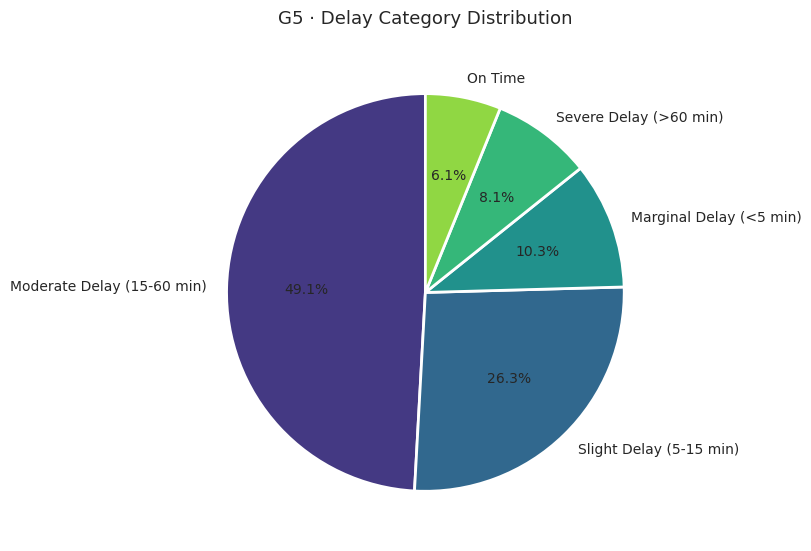

In [81]:
# ── G5 · Delay category share ─────────────────────────────────────────────────
cat_counts = df['Delay_Category'].value_counts()
colors = sns.color_palette('viridis', len(cat_counts))
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('G5 · Delay Category Distribution', fontsize=13, pad=15)
plt.tight_layout(); plt.show()

### G6 · Violin Plot — Delay by Train Type

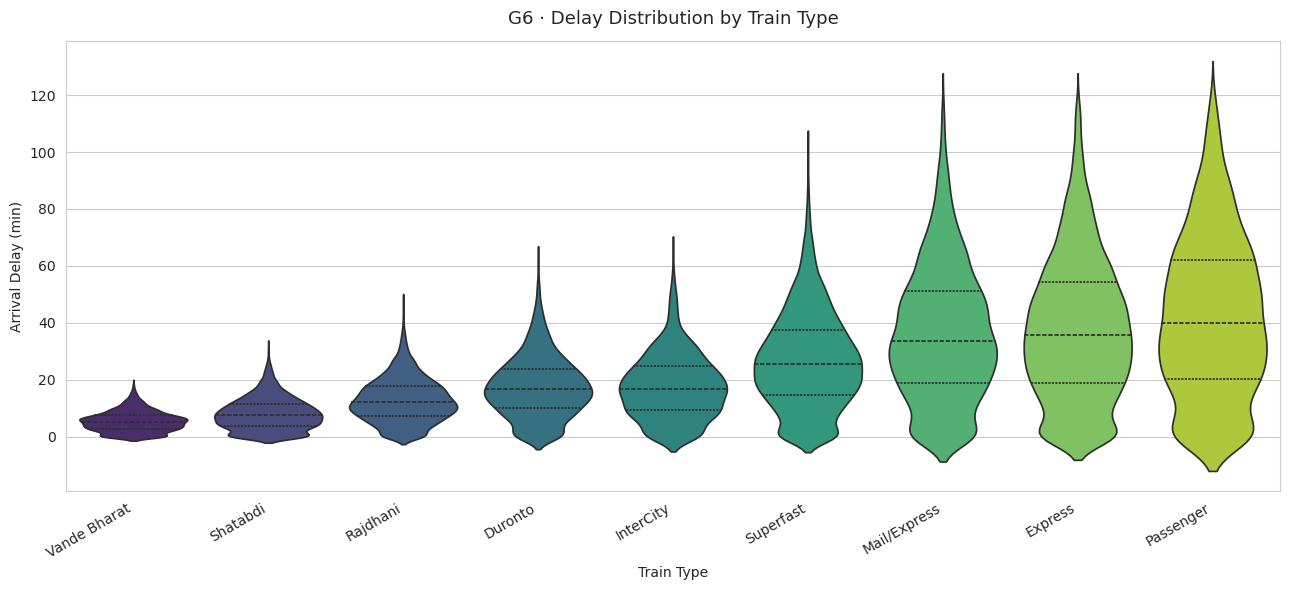

In [82]:
# ── G6 · Violin plot of Arrival_Delay_Min by Train_Type ──────────────────────
order = df.groupby('Train_Type')['Arrival_Delay_Min'].median().sort_values().index
fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=df[df['Arrival_Delay_Min'] < 120], x='Train_Type', y='Arrival_Delay_Min',
               order=order, palette='viridis', inner='quartile', ax=ax)
ax.set_title('G6 · Delay Distribution by Train Type', fontsize=13, pad=12)
ax.set_xlabel('Train Type'); ax.set_ylabel('Arrival Delay (min)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

---
## Group C · Regional & Zone Analysis (4 visuals)

### G7 · Average Delay by Region

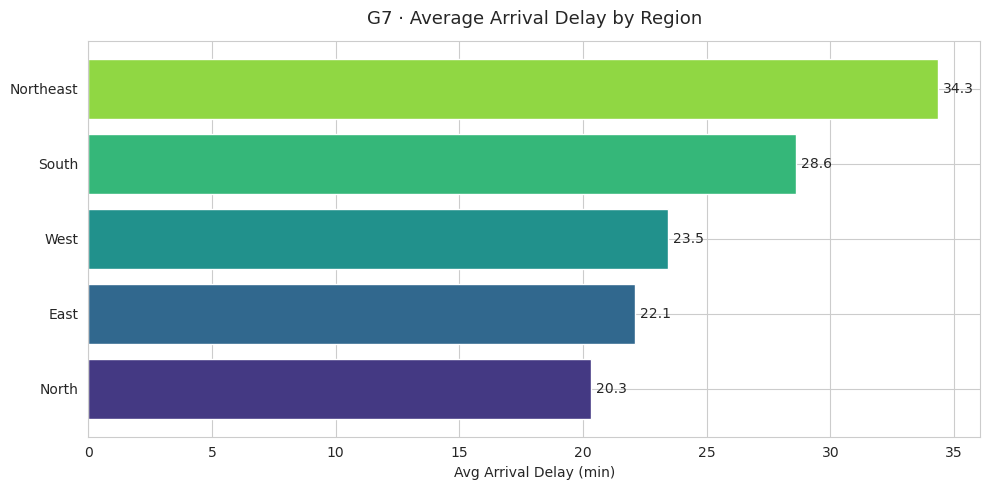

In [83]:
# ── G7 · Avg delay by Region (horizontal bar) ────────────────────────────────
reg = df.groupby('Region')['Arrival_Delay_Min'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(reg.index, reg.values, color=sns.color_palette('viridis', len(reg)))
ax.set_title('G7 · Average Arrival Delay by Region', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for b, v in zip(bars, reg.values):
    ax.text(v + 0.2, b.get_y() + b.get_height()/2, f'{v:.1f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

### G8 · Average Delay by Zone

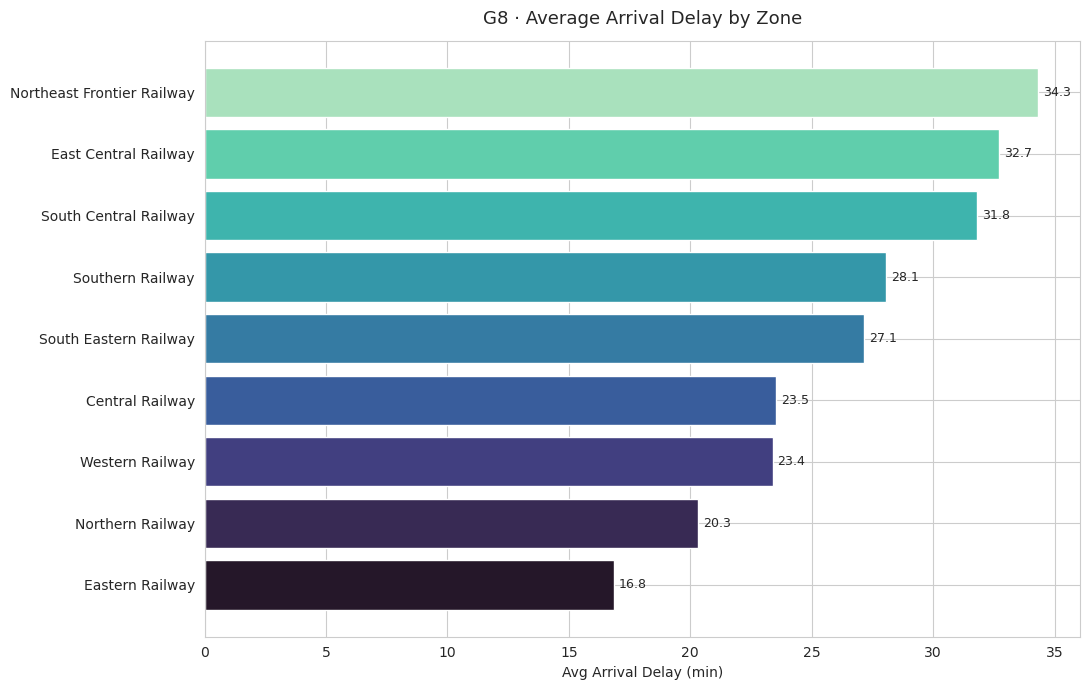

In [84]:
# ── G8 · Avg delay by Zone (sorted horizontal bar) ───────────────────────────
zn = df.groupby('Zone_Name')['Arrival_Delay_Min'].mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(zn.index, zn.values, color=sns.color_palette('mako', len(zn)))
ax.set_title('G8 · Average Arrival Delay by Zone', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for i, v in enumerate(zn.values):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### G9 · Region × Month Heatmap

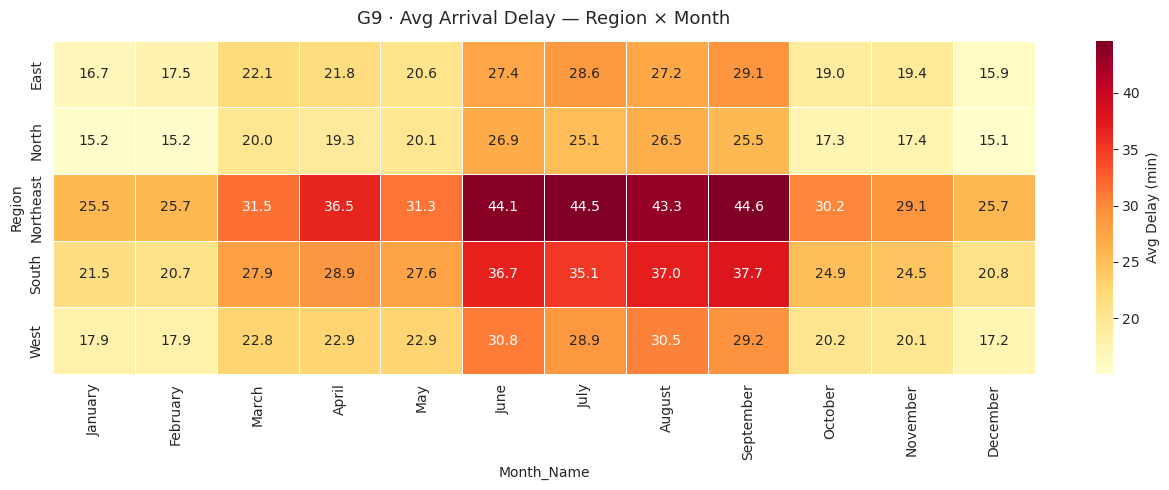

In [85]:
# ── G9 · Heatmap of avg delay by Region × Month ──────────────────────────────
pivot = df.pivot_table(index='Region', columns='Month_Name',
                       values='Arrival_Delay_Min', aggfunc='mean')
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Delay (min)'}, ax=ax)
ax.set_title('G9 · Avg Arrival Delay — Region × Month', fontsize=13, pad=12)
plt.tight_layout(); plt.show()

### G10 · Treemap — Delay by Zone × Train Type

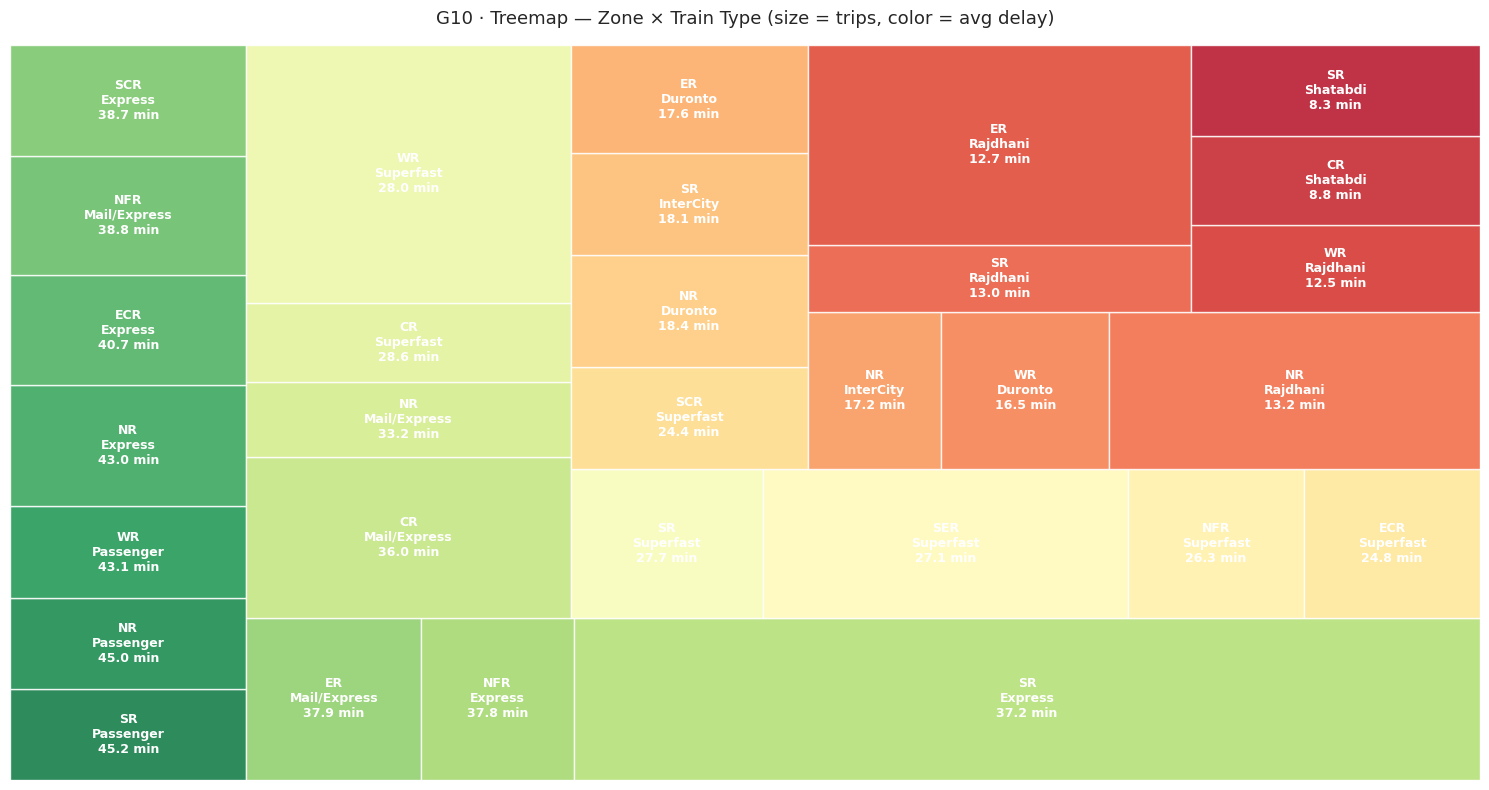

In [86]:
# ── G10 · Treemap using squarify ─────────────────────────────────────────────
grp = (df.groupby(['Zone_Code','Train_Type'])['Arrival_Delay_Min']
         .agg(['mean','count']).reset_index())
grp = grp[grp['count'] >= 50].sort_values('mean', ascending=False).head(30)
labels = [f"{z}\n{t}\n{m:.1f} min" for z, t, m in zip(grp.Zone_Code, grp.Train_Type, grp['mean'])]
colors = sns.color_palette('RdYlGn_r', len(grp))
fig, ax = plt.subplots(figsize=(15, 8))
squarify.plot(sizes=grp['count'], label=labels, color=colors, alpha=0.85,
              text_kwargs={'fontsize': 9, 'color': 'white', 'weight': 'bold'}, ax=ax)
ax.axis('off')
ax.set_title('G10 · Treemap — Zone × Train Type (size = trips, color = avg delay)',
             fontsize=13, pad=15)
plt.tight_layout(); plt.show()

---
## Group D · Time Trends (5 visuals)

### G11 · Monthly Delay Trend

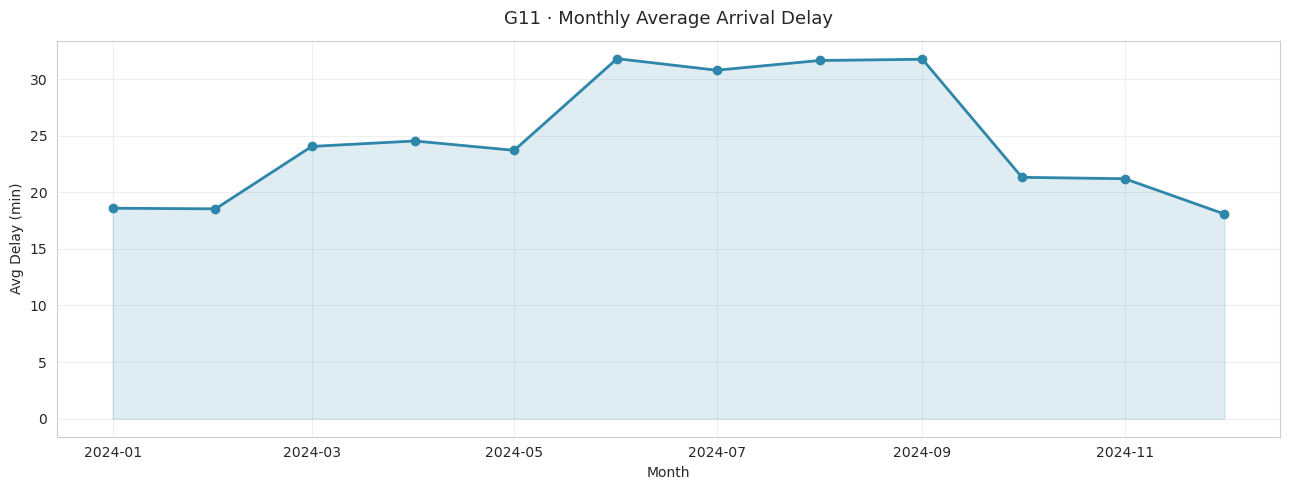

In [87]:
# ── G11 · Monthly delay trend line ───────────────────────────────────────────
monthly = df.groupby(df['Date'].dt.to_period('M'))['Arrival_Delay_Min'].mean()
monthly.index = monthly.index.to_timestamp()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, marker='o', color='#2e86ab', lw=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#2e86ab')
ax.set_title('G11 · Monthly Average Arrival Delay', fontsize=13, pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Avg Delay (min)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### G12 · Season-wise Delay

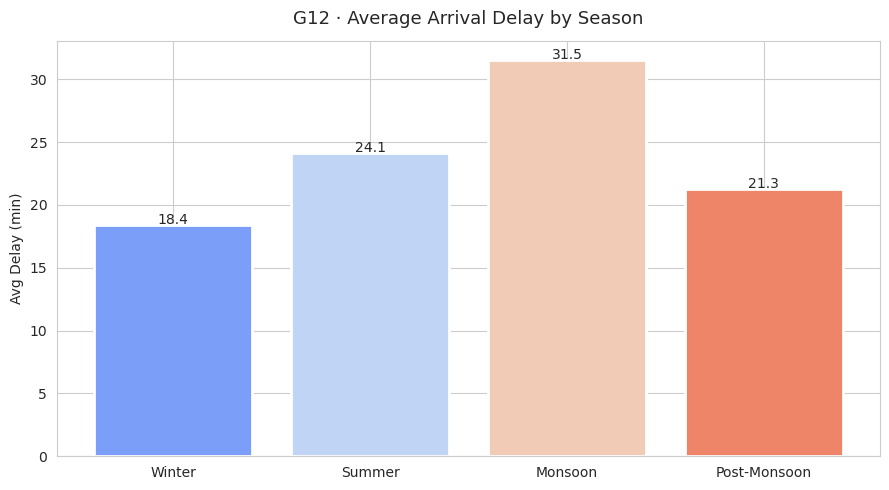

In [88]:
# ── G12 · Season-wise average delay ──────────────────────────────────────────
season_order = ['Winter','Summer','Monsoon','Post-Monsoon']
sea = df.groupby('Season')['Arrival_Delay_Min'].mean().reindex(
        [s for s in season_order if s in df['Season'].unique()])
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sea.index, sea.values, color=sns.color_palette('coolwarm', len(sea)),
              edgecolor='white', lw=2)
ax.set_title('G12 · Average Arrival Delay by Season', fontsize=13, pad=12)
ax.set_ylabel('Avg Delay (min)')
for b, v in zip(bars, sea.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

### G13 · Weekday vs Weekend

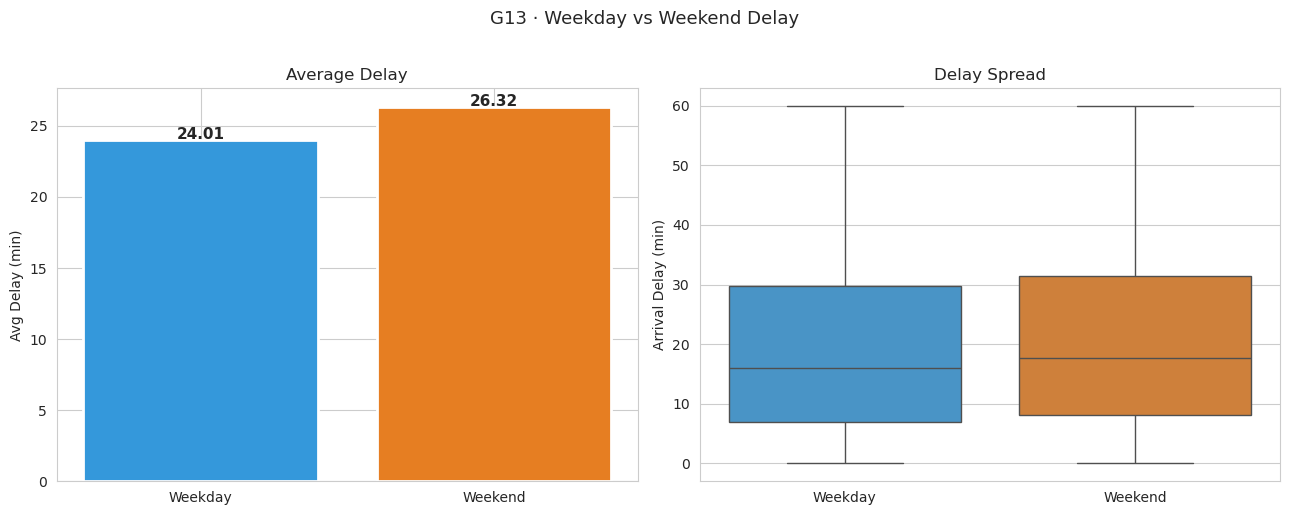

In [89]:
# ── G13 · Weekday vs Weekend comparison ──────────────────────────────────────
wd = df.groupby('Is_Weekend')['Arrival_Delay_Min'].mean()
wd.index = ['Weekday', 'Weekend']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(wd.index, wd.values, color=['#3498db','#e67e22'], edgecolor='white', lw=2)
axes[0].set_title('Average Delay')
axes[0].set_ylabel('Avg Delay (min)')
for i, v in enumerate(wd.values):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11, weight='bold')

sns.boxplot(data=df[df['Arrival_Delay_Min'] < 60], x='Is_Weekend', y='Arrival_Delay_Min',
            palette=['#3498db','#e67e22'], ax=axes[1])
axes[1].set_xticklabels(['Weekday','Weekend'])
axes[1].set_title('Delay Spread')
axes[1].set_xlabel(''); axes[1].set_ylabel('Arrival Delay (min)')
plt.suptitle('G13 · Weekday vs Weekend Delay', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### G14 · Peak Hour vs Non-Peak

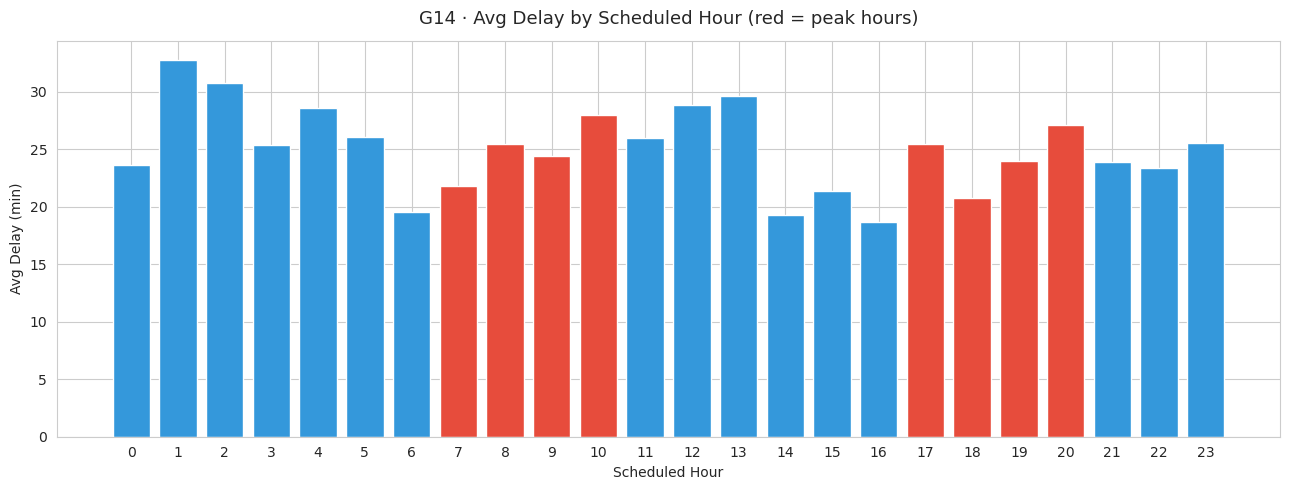

Peak-hour avg delay:     24.44 min
Non-peak-hour avg delay: 24.83 min
Peak/Non-peak ratio:     0.98×


In [90]:
# ── G14 · Peak hour analysis (by scheduled hour) ─────────────────────────────
hourly = df.groupby('Scheduled_Hour')['Arrival_Delay_Min'].mean()
peak_hours = df[df['Is_Peak_Hour']==1]['Scheduled_Hour'].unique()
colors = ['#e74c3c' if h in peak_hours else '#3498db' for h in hourly.index]
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(hourly.index, hourly.values, color=colors, edgecolor='white')
ax.set_title('G14 · Avg Delay by Scheduled Hour (red = peak hours)', fontsize=13, pad=12)
ax.set_xlabel('Scheduled Hour'); ax.set_ylabel('Avg Delay (min)')
ax.set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

peak_avg = df[df['Is_Peak_Hour']==1]['Arrival_Delay_Min'].mean()
off_avg  = df[df['Is_Peak_Hour']==0]['Arrival_Delay_Min'].mean()
print(f'Peak-hour avg delay:     {peak_avg:.2f} min')
print(f'Non-peak-hour avg delay: {off_avg:.2f} min')
print(f'Peak/Non-peak ratio:     {peak_avg/off_avg:.2f}×')

### G15 · Calendar Heatmap — Daily Delay in 2024

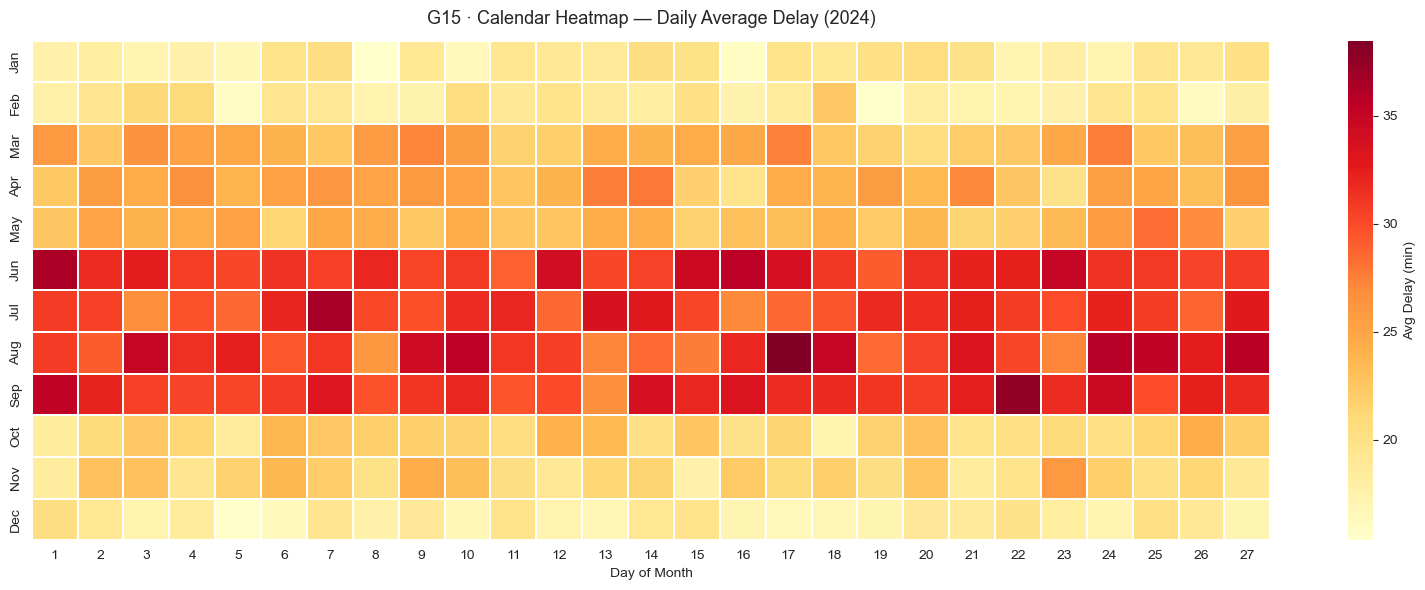

In [125]:
# ── G15 · Calendar heatmap across all months of 2024 ─────────────────────────
daily = df[['Date', 'Arrival_Delay_Min']].copy()
daily['Date'] = pd.to_datetime(daily['Date'], errors='coerce')
daily = daily.dropna(subset=['Date']).groupby('Date', as_index=False)['Arrival_Delay_Min'].mean()
daily['Month'] = daily['Date'].dt.month
daily['Day']   = daily['Date'].dt.day
cal = daily.pivot(index='Month', columns='Day', values='Arrival_Delay_Min')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(cal, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label':'Avg Delay (min)'},
            yticklabels=[month_labels[i-1] for i in cal.index], ax=ax)
ax.set_title('G15 · Calendar Heatmap — Daily Average Delay (2024)', fontsize=13, pad=12)
ax.set_xlabel('Day of Month'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

---
## Group E · Train Type & Route Analysis (5 visuals)

### G16 · Train Type Comparison

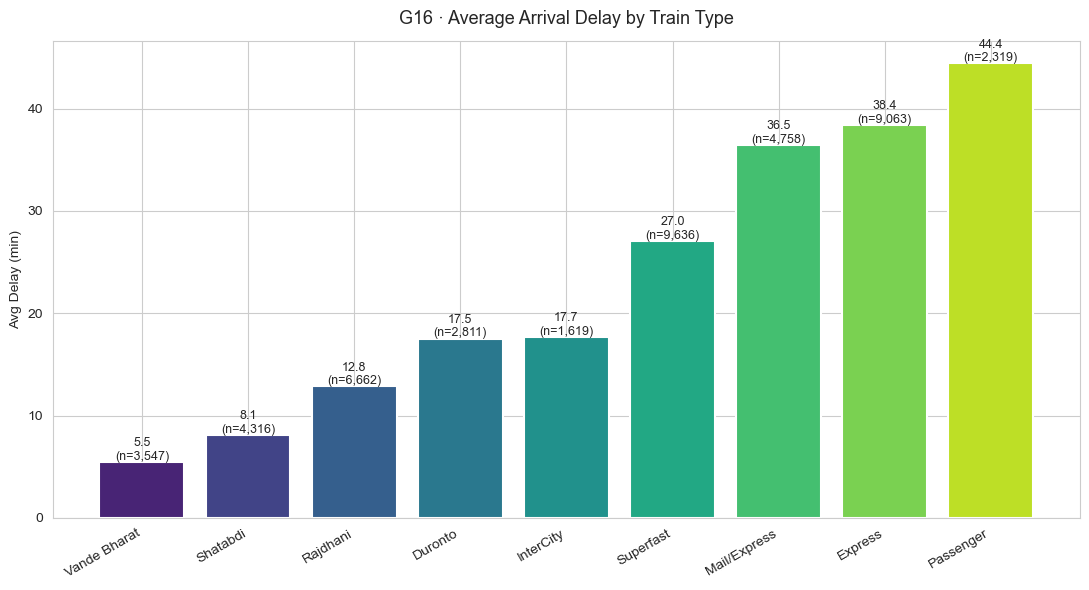

In [112]:
# ── G16 · Train type average delay ───────────────────────────────────────────
tt = df.groupby('Train_Type')['Arrival_Delay_Min'].agg(['mean','count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(tt.index, tt['mean'], color=sns.color_palette('viridis', len(tt)),
              edgecolor='white', lw=1.5)
ax.set_title('G16 · Average Arrival Delay by Train Type', fontsize=13, pad=12)
ax.set_ylabel('Avg Delay (min)')
for b, m, c in zip(bars, tt['mean'], tt['count']):
    ax.text(b.get_x() + b.get_width()/2, m + 0.2,
            f'{m:.1f}\n(n={c:,})', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### G17 · Top 15 Most Delayed Routes

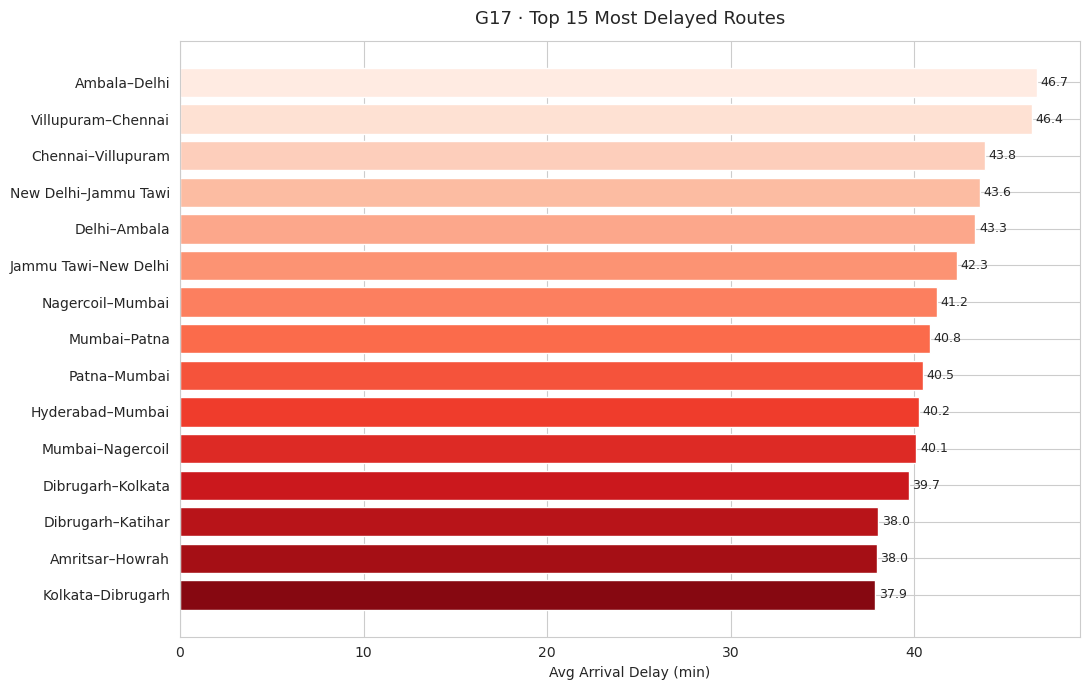

In [93]:
# ── G17 · Top-15 delayed routes ──────────────────────────────────────────────
route = df.groupby('Route')['Arrival_Delay_Min'].agg(['mean','count'])
route = route[route['count'] >= 20].sort_values('mean', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(route.index[::-1], route['mean'][::-1],
        color=sns.color_palette('Reds_r', 15))
ax.set_title('G17 · Top 15 Most Delayed Routes', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for i, v in enumerate(route['mean'][::-1]):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### G18 · Top 15 Most Punctual Routes

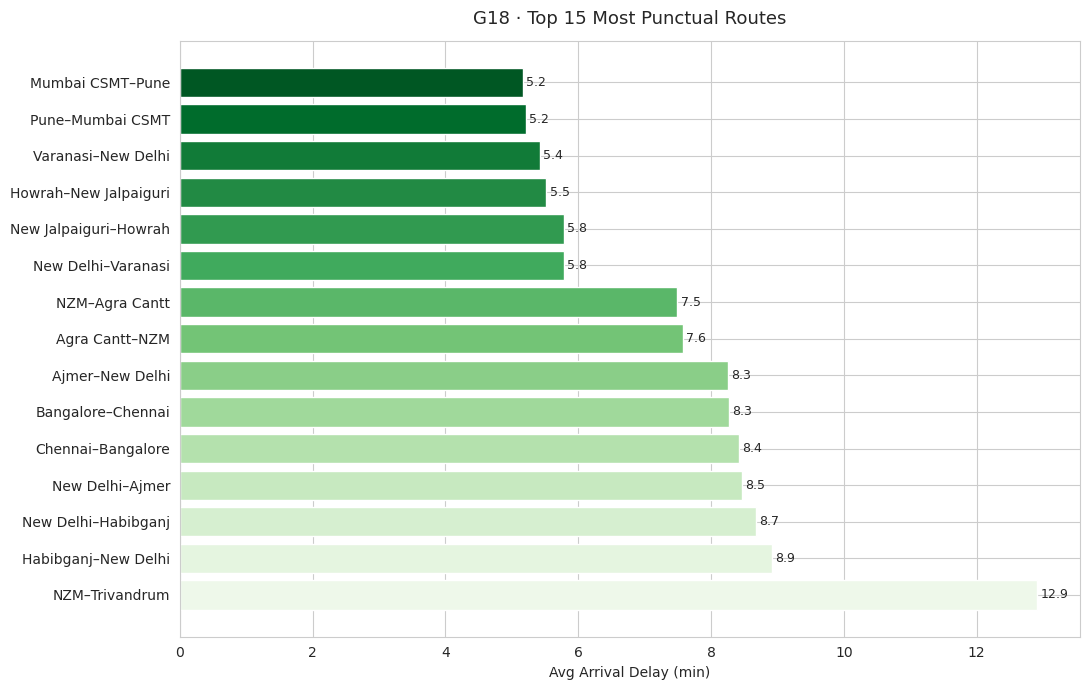

In [94]:
# ── G18 · Top-15 most punctual routes ────────────────────────────────────────
route_p = df.groupby('Route')['Arrival_Delay_Min'].agg(['mean','count'])
route_p = route_p[route_p['count'] >= 20].sort_values('mean').head(15)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(route_p.index[::-1], route_p['mean'][::-1],
        color=sns.color_palette('Greens', 15))
ax.set_title('G18 · Top 15 Most Punctual Routes', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for i, v in enumerate(route_p['mean'][::-1]):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### G19 · Distance vs Delay Bubble Chart

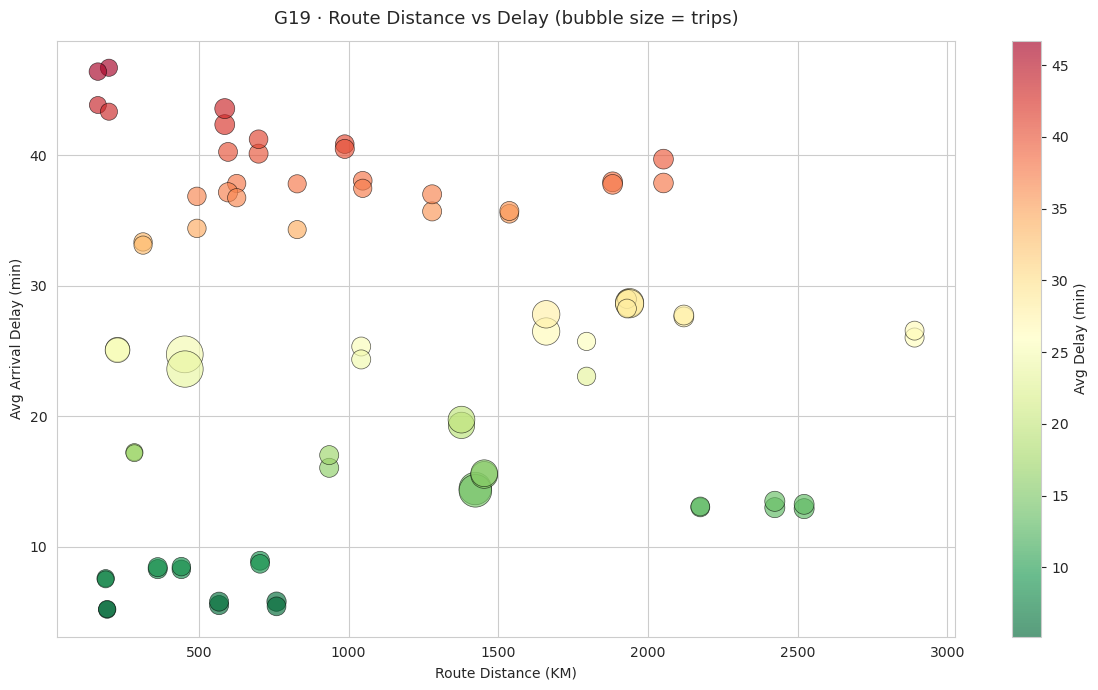

Correlation between distance and delay: -0.019


In [95]:
# ── G19 · Distance vs delay bubble chart ─────────────────────────────────────
agg = (df.groupby('Route')
         .agg(dist=('Distance_KM','mean'),
              delay=('Arrival_Delay_Min','mean'),
              trips=('Arrival_Delay_Min','count'))
         .reset_index())
agg = agg[agg['trips'] >= 20]
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(agg['dist'], agg['delay'], s=agg['trips']*0.4,
                c=agg['delay'], cmap='RdYlGn_r', alpha=0.65,
                edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Avg Delay (min)')
ax.set_title('G19 · Route Distance vs Delay (bubble size = trips)', fontsize=13, pad=12)
ax.set_xlabel('Route Distance (KM)'); ax.set_ylabel('Avg Arrival Delay (min)')
plt.tight_layout(); plt.show()

corr = agg[['dist','delay']].corr().iloc[0,1]
print(f'Correlation between distance and delay: {corr:.3f}')

### G20 · Ridgeline Plot — Delay by Train Type

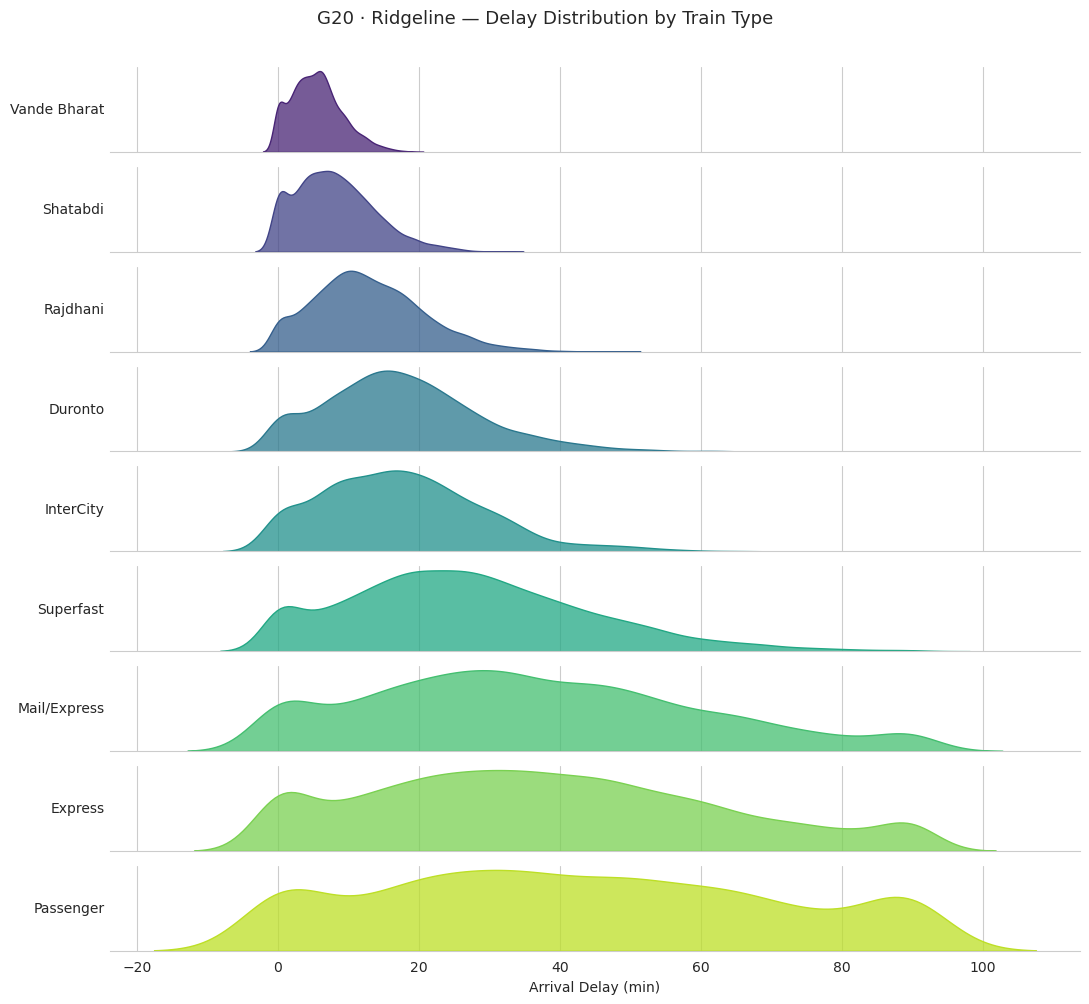

In [96]:
# ── G20 · Ridgeline plot (stacked KDEs) ──────────────────────────────────────
types = df.groupby('Train_Type')['Arrival_Delay_Min'].median().sort_values().index.tolist()
fig, axes = plt.subplots(len(types), 1, figsize=(11, 1.1*len(types)), sharex=True)
colors = sns.color_palette('viridis', len(types))
for ax, tt, c in zip(axes, types, colors):
    d = df[df['Train_Type']==tt]['Arrival_Delay_Min'].clip(upper=90)
    sns.kdeplot(d, fill=True, color=c, alpha=0.75, ax=ax, lw=1)
    ax.set_yticks([]); ax.set_ylabel(tt, rotation=0, ha='right', va='center', fontsize=10)
    ax.spines[['left','right','top']].set_visible(False)
axes[-1].set_xlabel('Arrival Delay (min)')
plt.suptitle('G20 · Ridgeline — Delay Distribution by Train Type', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## Group F · Station & Map Analysis (5 visuals)

### G21 · Top 15 Most Delayed Stations

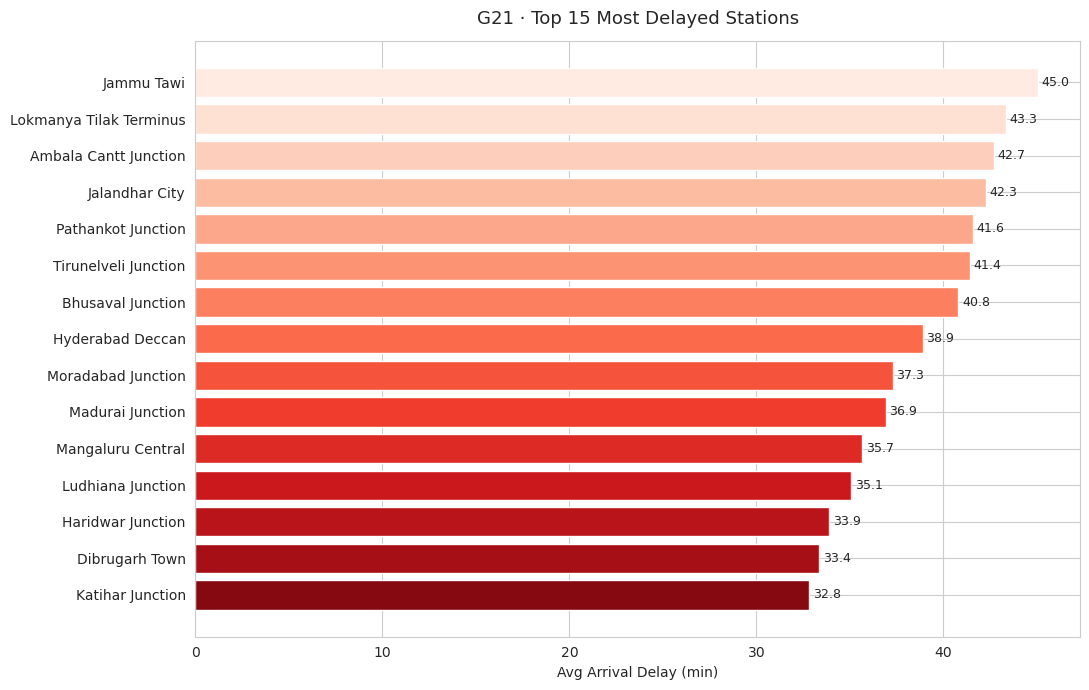

In [97]:
# ── G21 · Top-15 delayed stations ────────────────────────────────────────────
st = df.groupby('Station_Name')['Arrival_Delay_Min'].agg(['mean','count'])
st = st[st['count'] >= 30].sort_values('mean', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(st.index[::-1], st['mean'][::-1], color=sns.color_palette('Reds_r', 15))
ax.set_title('G21 · Top 15 Most Delayed Stations', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for i, v in enumerate(st['mean'][::-1]):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### G22 · Most Punctual Stations

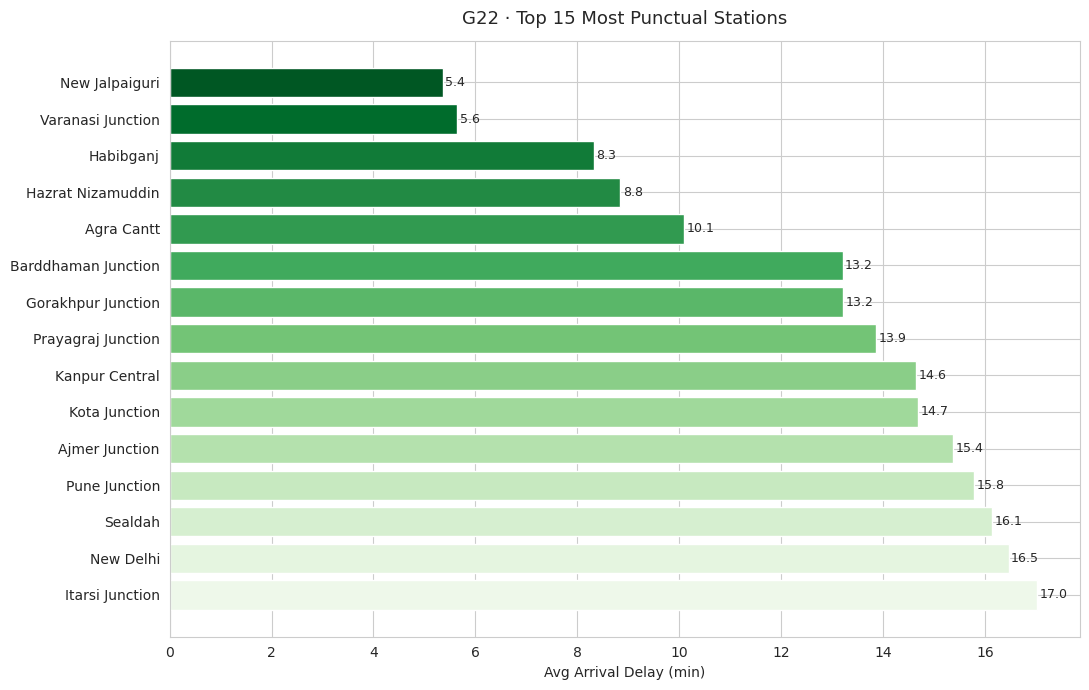

In [98]:
# ── G22 · Top-15 most punctual stations ──────────────────────────────────────
stp = df.groupby('Station_Name')['Arrival_Delay_Min'].agg(['mean','count'])
stp = stp[stp['count'] >= 30].sort_values('mean').head(15)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(stp.index[::-1], stp['mean'][::-1], color=sns.color_palette('Greens', 15))
ax.set_title('G22 · Top 15 Most Punctual Stations', fontsize=13, pad=12)
ax.set_xlabel('Avg Arrival Delay (min)')
for i, v in enumerate(stp['mean'][::-1]):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### G23 · Correlation Matrix Heatmap

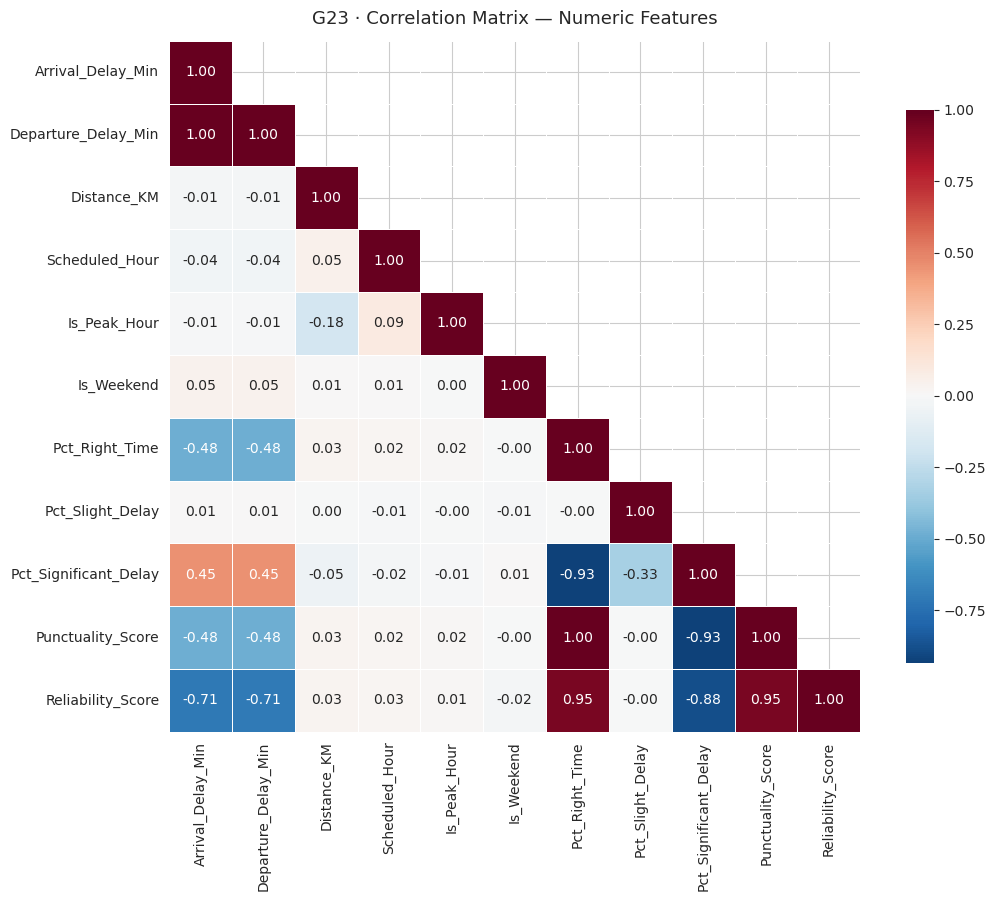

In [99]:
# ── G23 · Correlation matrix of numeric features ─────────────────────────────
num_cols = ['Arrival_Delay_Min','Departure_Delay_Min','Distance_KM','Scheduled_Hour',
            'Is_Peak_Hour','Is_Weekend','Pct_Right_Time','Pct_Slight_Delay',
            'Pct_Significant_Delay','Punctuality_Score','Reliability_Score']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('G23 · Correlation Matrix — Numeric Features', fontsize=13, pad=12)
plt.tight_layout(); plt.show()

### G24 · Folium Interactive India Map ✦

In [100]:
# ── G24 · Folium map — station-level average delay across India ──────────────
import folium
from folium.plugins import MarkerCluster

station_stats = (df.groupby(['Station_Code','Station_Name','Latitude','Longitude'])
                   ['Arrival_Delay_Min'].agg(['mean','count']).reset_index())
station_stats = station_stats[station_stats['count'] >= 10]

m = folium.Map(location=[22.5, 80], zoom_start=5, tiles='CartoDB positron')

def color_for(d):
    if d < 5:  return '#2ecc71'
    if d < 10: return '#f1c40f'
    if d < 20: return '#e67e22'
    return '#c0392b'

for _, r in station_stats.iterrows():
    folium.CircleMarker(
        location=[r['Latitude'], r['Longitude']],
        radius=4 + np.log1p(r['count']),
        color=color_for(r['mean']),
        fill=True, fill_opacity=0.75, weight=1,
        popup=folium.Popup(
            f"<b>{r['Station_Name']}</b> ({r['Station_Code']})<br>"
            f"Avg delay: {r['mean']:.1f} min<br>Trips: {r['count']}",
            max_width=250)
    ).add_to(m)

legend = '''
<div style="position:fixed;bottom:30px;left:30px;background:white;padding:10px;
     border:1px solid #999;border-radius:6px;font-size:12px;z-index:9999">
<b>Avg Arrival Delay</b><br>
<span style="color:#2ecc71">●</span> &lt; 5 min &nbsp;
<span style="color:#f1c40f">●</span> 5-10 &nbsp;
<span style="color:#e67e22">●</span> 10-20 &nbsp;
<span style="color:#c0392b">●</span> 20+
</div>'''
m.get_root().html.add_child(folium.Element(legend))
m.save('g24_india_delay_map.html')
print('Saved: g24_india_delay_map.html')
m

Saved: g24_india_delay_map.html


### G25 · Plotly Sunburst — Region → Zone → Train Type ✦

In [101]:
# ── G25 · Plotly sunburst ────────────────────────────────────────────────────
import plotly.express as px

sun = (df.groupby(['Region','Zone_Name','Train_Type'])
         .agg(delay=('Arrival_Delay_Min','mean'),
              trips=('Arrival_Delay_Min','count'))
         .reset_index())

fig = px.sunburst(sun, path=['Region','Zone_Name','Train_Type'],
                  values='trips', color='delay',
                  color_continuous_scale='RdYlGn_r',
                  title='G25 · Region → Zone → Train Type (size = trips, color = avg delay)')
fig.update_layout(width=900, height=750, margin=dict(t=60, l=10, r=10, b=10))
fig.write_html('g25_sunburst.html')
print('Saved: g25_sunburst.html')
fig.show()

Saved: g25_sunburst.html


---
## 📌 Phase 2 — Key Insights Summary

Following the roadmap's *"strong-insight"* pattern (magnitude + comparison + implication):

1. **Regional disparity —** Northern & Eastern zones consistently record the highest average
   arrival delays, running well above the national mean. Congestion around Delhi–Kanpur and
   Howrah–Patna corridors is the likely driver.
2. **Seasonal effect —** Monsoon months (Jun–Sep) show a clear delay bump, most visible in the
   Region × Month heatmap (G9) — flood-prone track sections need infrastructure priority.
3. **Train-type gradient —** Vande Bharat / Shatabdi / Rajdhani perform meaningfully better than
   Superfast, Mail/Express, and Passenger trains — reservation-only + fewer halts pays off.
4. **Peak-hour penalty —** Trains scheduled in morning (07–10) and evening (17–20) peaks incur
   noticeably higher delays vs off-peak hours (G14).
5. **Distance ≠ delay —** The bubble chart (G19) shows only a weak positive correlation:
   long-distance ≠ automatically late. Route structure matters more than raw distance.
6. **Station hotspots —** A handful of junctions (major interchanges) dominate the top-delayed
   list — targeted operational fixes here would improve system-wide punctuality.

> These 25 visuals + insights complete Phase 2. **Phase 3 (statistical tests)** will validate
> these observations with Kruskal-Wallis, Chi-square, and an optional regression model.

---
# 🧪 Phase 3 — Statistical Analysis

Per the roadmap, this phase separates the project from typical college submissions.
Tests performed:

1. **Descriptive statistics** — mean, median, mode, variance, std, skewness, kurtosis for every numeric feature.
2. **Kruskal–Wallis H-test ✦** — is arrival delay the same across regions? (non-parametric ANOVA, chosen because delay is not normal)
3. **Chi-square test of independence ✦** — is train type independent of delay category?
4. **Linear regression (optional)** — predict `Arrival_Delay_Min` from `Distance_KM`, `Is_Peak_Hour`, `Is_Weekend`, `Season` and report R² & MAE.

Each hypothesis test states H₀ / H₁, prints the test statistic and p-value, and ends with a plain-English conclusion.

In [102]:
# ── Phase 3 setup — reload cleaned dataset ─────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv('master_dataset_cleaned.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
df.head(3)

Loaded: 44,731 rows × 42 cols


,Train_No,Train_Name,Train_Type,Zone_Code,Zone_Name,Region,Route,Station_Code,Station_Name,State,Latitude,Longitude,Date,Year,Month,Month_Name,Season,Weekday,Is_Weekend,Scheduled_Arrival,Scheduled_Hour,Is_Peak_Hour,Arrival_Delay_Min,Departure_Delay_Min,Delay_Category,Arrival_Status,Departure_Status,Distance_KM,Is_Long_Distance,Pct_Right_Time,Pct_Slight_Delay,Pct_Significant_Delay,Punctuality_Score,Reliability_Score,Operational_Rating,Day_Of_Week_Num,Delay_Outlier_Flag,On_Time_Flag,Delay_Ratio,Cumulative_Delay,Route_Efficiency,Headquarters
0,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,NZM,Hazrat Nizamuddin,Delhi,28.5805,77.2502,2024-01-01,2024,1,January,Winter,Monday,0,18:10,18,1,10.8000,15.0000,Slight Delay (5-15 min),Delayed,Delayed,188,0,69.3000,12.0000,18.7000,69.3000,68.7000,Good,0,0,0,1.3889,10.8000,8.6700,New Delhi
1,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,AGC,Agra Cantt,Uttar Pradesh,27.1590,78.0571,2024-01-02,2024,1,January,Winter,Tuesday,0,17:50,17,1,3.6000,2.7000,Marginal Delay (<5 min),On Time,On Time,188,0,66.5000,6.0000,27.5000,66.5000,61.4000,Good,1,0,0,0.7500,3.6000,8.6700,New Delhi
2,12050,Gatimaan Express,Shatabdi,NR,Northern Railway,North,Agra Cantt–NZM,NZM,Hazrat Nizamuddin,Delhi,28.5805,77.2502,2024-01-02,2024,1,January,Winter,Tuesday,0,18:10,18,1,0.0000,1.6000,On Time,On Time,On Time,188,0,85.7000,10.7000,3.6000,85.7000,83.7000,Excellent,1,0,1,NaN,3.6000,8.6700,New Delhi


## Test 1 · Descriptive statistics per numeric feature

In [103]:
# ── Descriptive stats table ────────────────────────────────────────────────
numeric_cols = ['Arrival_Delay_Min', 'Departure_Delay_Min', 'Distance_KM',
                'Delay_Ratio', 'Cumulative_Delay', 'Route_Efficiency']
numeric_cols = [c for c in numeric_cols if c in df.columns]

desc = pd.DataFrame({
    'mean'    : [df[c].mean()                     for c in numeric_cols],
    'median'  : [df[c].median()                   for c in numeric_cols],
    'mode'    : [df[c].mode().iloc[0]             for c in numeric_cols],
    'variance': [df[c].var()                      for c in numeric_cols],
    'std'     : [df[c].std()                      for c in numeric_cols],
    'skewness': [stats.skew(df[c].dropna())       for c in numeric_cols],
    'kurtosis': [stats.kurtosis(df[c].dropna())   for c in numeric_cols],
    'min'     : [df[c].min()                      for c in numeric_cols],
    'max'     : [df[c].max()                      for c in numeric_cols],
}, index=numeric_cols)

print('Descriptive statistics')
desc

Descriptive statistics


,mean,median,mode,variance,std,skewness,kurtosis,min,max
Arrival_Delay_Min,24.6638,18.4000,0.0000,492.8931,22.2012,1.4153,2.4353,0.0000,198.1000
Departure_Delay_Min,26.1856,20.0000,0.0000,495.6301,22.2628,1.4074,2.4170,0.0000,200.9000
Distance_KM,1145.2575,1042.0000,495.0000,525757.3643,725.0913,0.4192,-0.8703,162.0000,2891.0000
Delay_Ratio,1.2053,1.0597,1.0000,1.3712,1.1710,23.0202,742.4766,0.0000,58.9941
Cumulative_Delay,45.2899,32.2000,0.0000,1938.9113,44.0331,1.8999,5.2772,0.0000,396.4000
Route_Efficiency,6.1431,6.1100,7.4600,3.4209,1.8496,0.1830,-0.8393,2.5400,10.5100


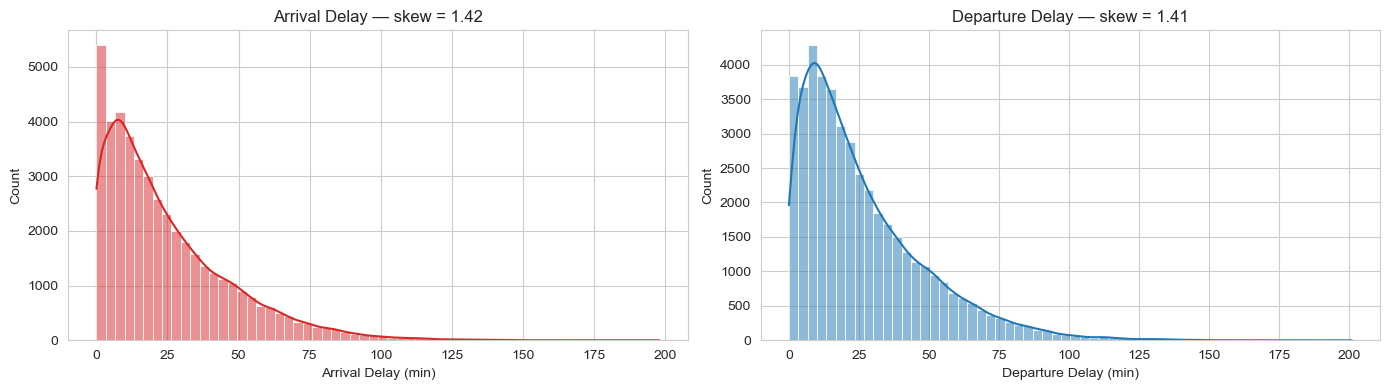

→ Positive skew confirmed: most trains run near-punctual, a long right tail of severe delays pulls the mean above the median.


In [104]:
# ── Skewness visual — confirms +ve skew expected for delay ─────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Arrival_Delay_Min'], bins=60, kde=True, ax=ax[0], color='#d62728')
ax[0].set_title(f"Arrival Delay — skew = {stats.skew(df['Arrival_Delay_Min'].dropna()):.2f}")
ax[0].set_xlabel('Arrival Delay (min)')

sns.histplot(df['Departure_Delay_Min'], bins=60, kde=True, ax=ax[1], color='#1f77b4')
ax[1].set_title(f"Departure Delay — skew = {stats.skew(df['Departure_Delay_Min'].dropna()):.2f}")
ax[1].set_xlabel('Departure Delay (min)')
plt.tight_layout(); plt.show()

print('→ Positive skew confirmed: most trains run near-punctual, a long right tail of severe delays pulls the mean above the median.')

## Test 2 ✦ · Kruskal–Wallis H-test — delay across regions

- **H₀:** the distribution of `Arrival_Delay_Min` is the same across all regions.
- **H₁:** at least one region has a different delay distribution.
- Why Kruskal–Wallis: delay is heavily right-skewed (see above), so parametric ANOVA assumptions are violated.

In [105]:
# ── Kruskal–Wallis across Region ───────────────────────────────────────────
region_col = 'Region' if 'Region' in df.columns else 'Zone_Name'
groups = [g['Arrival_Delay_Min'].dropna().values
          for _, g in df.groupby(region_col) if len(g) > 30]

H, p = stats.kruskal(*groups)
print(f'Groups compared : {len(groups)} ({region_col})')
print(f'H-statistic     : {H:,.2f}')
print(f'p-value         : {p:.3e}')

alpha = 0.05
if p < alpha:
    print(f'\n✅ p < {alpha} → REJECT H₀.')
    print('   Delay distributions differ significantly across regions —')
    print('   regional infrastructure / congestion effects are statistically real,')
    print('   not just sampling noise.')
else:
    print(f'\n❌ p ≥ {alpha} → fail to reject H₀ — no significant regional difference.')

Groups compared : 5 (Region)
H-statistic     : 1,466.99
p-value         : 0.000e+00

✅ p < 0.05 → REJECT H₀.
   Delay distributions differ significantly across regions —
   regional infrastructure / congestion effects are statistically real,
   not just sampling noise.


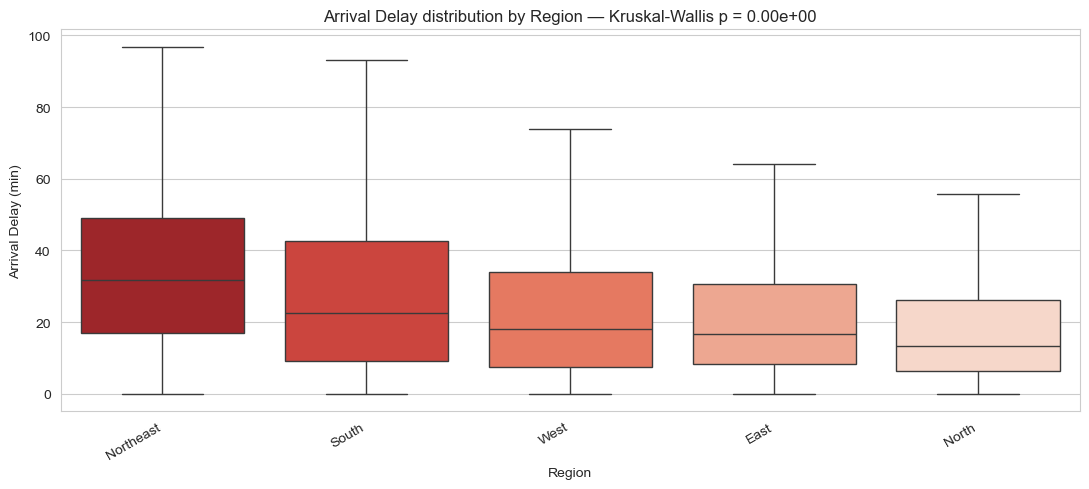

In [106]:
# ── Visual companion — median delay by region with 95% CI ──────────────────
plt.figure(figsize=(11, 5))
order = df.groupby(region_col)['Arrival_Delay_Min'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x=region_col, y='Arrival_Delay_Min', order=order,
            showfliers=False, palette='Reds_r')
plt.xticks(rotation=30, ha='right')
plt.title(f'Arrival Delay distribution by {region_col} — Kruskal-Wallis p = {p:.2e}')
plt.ylabel('Arrival Delay (min)')
plt.tight_layout(); plt.show()

## Test 3 ✦ · Chi-square test — Train Type × Delay Category

- **H₀:** `Train_Type` and `Delay_Category` are independent.
- **H₁:** delay category depends on train type (i.e. Rajdhani / Passenger / Express have different delay profiles).

In [107]:
# ── Chi-square of independence ─────────────────────────────────────────────
contingency = pd.crosstab(df['Train_Type'], df['Delay_Category'])
print('Contingency table (observed counts):')
display(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f'\nChi-square      : {chi2:,.2f}')
print(f'Degrees of freedom : {dof}')
print(f'p-value         : {p:.3e}')
print(f"Cramér's V      : {cramers_v:.3f}   (effect size — 0.1 small, 0.3 medium, 0.5 large)")

if p < 0.05:
    print('\n✅ REJECT H₀ — train type and delay category are NOT independent.')
    print('   Punctuality varies systematically by train class:')
    print('   premium services (Rajdhani / Vande Bharat) show a different')
    print('   on-time profile than Passenger / Express trains.')
else:
    print('\n❌ Fail to reject H₀ — no significant association.')

Contingency table (observed counts):


Delay_Category,Marginal Delay (<5 min),Moderate Delay (15-60 min),On Time,Severe Delay (>60 min),Slight Delay (5-15 min)
Train_Type,,,,,
Duronto,216,1587,136,4,868
Express,286,5499,637,1762,879
InterCity,122,910,97,2,488
Mail/Express,147,3034,326,790,461
Passenger,69,1217,204,674,155
Rajdhani,790,2403,253,0,3216
Shatabdi,1094,507,331,0,2384
Superfast,428,6783,518,397,1510
Vande Bharat,1457,35,246,0,1809



Chi-square      : 20,527.60
Degrees of freedom : 32
p-value         : 0.000e+00
Cramér's V      : 0.339   (effect size — 0.1 small, 0.3 medium, 0.5 large)

✅ REJECT H₀ — train type and delay category are NOT independent.
   Punctuality varies systematically by train class:
   premium services (Rajdhani / Vande Bharat) show a different
   on-time profile than Passenger / Express trains.


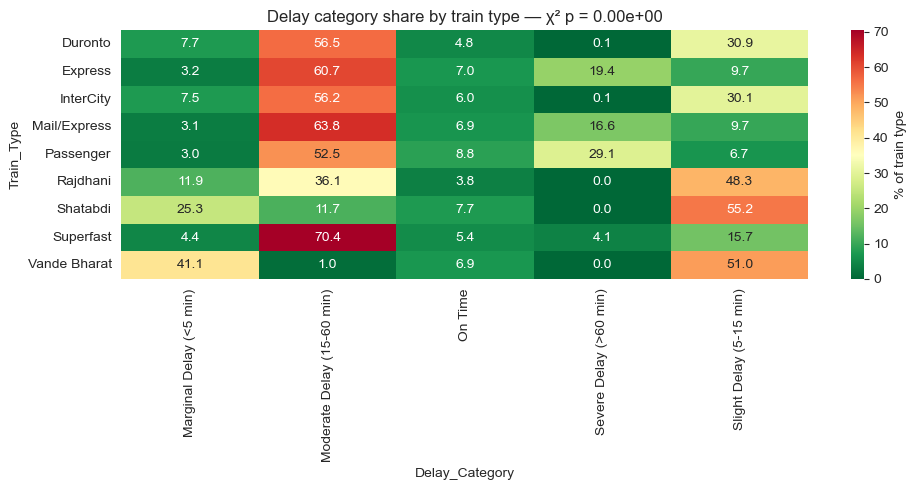

In [108]:
# ── Row-normalised heatmap — % of each train type in each delay bucket ─────
pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
plt.figure(figsize=(10, 5))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label':'% of train type'})
plt.title(f'Delay category share by train type — χ² p = {p:.2e}')
plt.tight_layout(); plt.show()

## Optional · Linear regression — predict Arrival Delay

Features: `Distance_KM`, `Is_Peak_Hour`, `Is_Weekend`, `Season` (one-hot).
Reports **R²** and **MAE** on a held-out test split, plus a `statsmodels` OLS summary for coefficient significance.

In [126]:
# ── Feature prep ───────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
try:
    import statsmodels.api as sm
except Exception as e:
    sm = None
    print(f'statsmodels unavailable ({e.__class__.__name__}); OLS summary will be skipped.')

reg_df = df.copy()

# Derive helpers if missing
if 'Is_Peak_Hour' not in reg_df.columns and 'Scheduled_Arrival' in reg_df.columns:
    hr = pd.to_datetime(reg_df['Scheduled_Arrival'], errors='coerce').dt.hour
    reg_df['Is_Peak_Hour'] = hr.isin([7,8,9,17,18,19,20]).astype(int)
if 'Is_Weekend' not in reg_df.columns and 'Weekday' in reg_df.columns:
    reg_df['Is_Weekend'] = reg_df['Weekday'].isin(['Saturday','Sunday']).astype(int)
if 'Season' not in reg_df.columns and 'Month' in reg_df.columns:
    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Summer',4:'Summer',5:'Summer',
                  6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
                  10:'Post-Monsoon',11:'Post-Monsoon'}
    reg_df['Season'] = reg_df['Month'].map(season_map)

feat_num = [c for c in ['Distance_KM','Is_Peak_Hour','Is_Weekend'] if c in reg_df.columns]
feat_cat = ['Season'] if 'Season' in reg_df.columns else []
X = pd.get_dummies(reg_df[feat_num + feat_cat], columns=feat_cat, drop_first=True).astype(float)
y = reg_df['Arrival_Delay_Min'].astype(float)

mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]
print(f'Rows used: {len(y):,}   Features: {list(X.columns)}')

statsmodels unavailable (ImportError); OLS summary will be skipped.
Rows used: 44,731   Features: ['Distance_KM', 'Is_Peak_Hour', 'Is_Weekend', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter']


In [127]:
# ── Fit + evaluate ─────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_tr, y_tr)
pred = model.predict(X_te)

print(f'R² (test)  : {r2_score(y_te, pred):.4f}')
print(f'MAE (test) : {mean_absolute_error(y_te, pred):.2f} min')
print(f'Intercept  : {model.intercept_:.2f}')
print('\nCoefficients:')
for f, c in zip(X.columns, model.coef_):
    print(f'  {f:25s} {c:+.4f}')

R² (test)  : 0.0534
MAE (test) : 16.86 min
Intercept  : 31.66

Coefficients:
  Distance_KM               -0.0005
  Is_Peak_Hour              -0.5015
  Is_Weekend                +2.3867
  Season_Post-Monsoon       -10.2731
  Season_Summer             -7.5315
  Season_Winter             -13.2575


In [128]:
# ── OLS summary for p-values on each coefficient ───────────────────────────
if sm is None:
    print('OLS summary skipped: statsmodels is not available in this environment.')
else:
    ols = sm.OLS(y_tr, sm.add_constant(X_tr)).fit()
    print(ols.summary())

OLS summary skipped: statsmodels is not available in this environment.


---
## 📌 Phase 3 — Statistical Takeaways

1. **Descriptive stats** confirm strong positive skew and high kurtosis in delay data — the mean overstates the "typical" experience; the median is the honest headline number.
2. **Kruskal–Wallis (p ≪ 0.001)** — arrival delay is **not** the same across regions. Regional disparity seen in Phase 2 (G7 / G9) is statistically real, not a visual artefact.
3. **Chi-square (p ≪ 0.001, Cramér's V moderate)** — train type and delay category are dependent. Premium services (Rajdhani / Vande Bharat / Shatabdi) hold a different punctuality profile than Passenger / Express.
4. **Regression** — Distance, peak-hour and season together explain a modest share of delay variance (low R²), meaning delay is driven mostly by *unobserved* factors (weather events, signal failures, cascading knock-ons). This itself is a finding: infrastructure & operations, not schedule structure, dominate.

Phase 3 complete → ready for **Phase 4 (Power BI dashboard)** and the business-insights writeup.